# Customer Churn Prediction Using Machine Learning

## Business Problem

Customer churn can reduce revenue, profitability, and long-term customer value. Identifying customers at risk of leaving allows businesses to prioritize retention efforts before disengagement becomes permanent.

This project develops an end-to-end machine learning framework to predict customer churn using historical transaction data from a UK-based online retailer. A time-based prediction approach is used to reflect how churn models would operate in practice, with past customer behavior used to predict future inactivity.

## Project Objectives

- Engineer customer-level behavioral features from transaction data
- Define churn using a realistic future observation window
- Compare multiple classification models
- Evaluate performance using metrics beyond accuracy
- Identify key drivers of churn
- Translate model results into actionable retention strategies

## Dataset

This project uses the **Online Retail dataset** from the **UCI Machine Learning Repository**. It contains more than 540,000 transactions recorded by a UK-based online retailer between December 2010 and December 2011.

Each row represents an individual transaction and includes:

- Customer ID
- Invoice number
- Invoice date
- Product description
- Quantity purchased
- Unit price
- Country

Because churn is measured at the customer level, the transaction data is later aggregated into customer-level behavioral features such as recency, frequency, spending, tenure, basket value, and product diversity.

## Data Loading and Initial Inspection

The dataset is first loaded and reviewed to confirm its structure, data types, completeness, and overall quality before cleaning and feature engineering.

This initial inspection focuses on:

- Dataset dimensions
- Column names and data types
- Sample records
- Missing values
- Potential data-quality issues

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

plt.style.use("default")
sns.set_theme(style="whitegrid")

In [2]:
# Load the transaction dataset
df = pd.read_csv(
    "E-commerce data.csv",
    encoding="ISO-8859-1"
)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

df.head()

Dataset shape: 541,909 rows × 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-10 8:26,3.39,17850.0,United Kingdom


In [3]:
# Review column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
# Summarize missing values
missing_summary = (
    df.isna()
    .sum()
    .to_frame("MissingValues")
    .assign(
        MissingPercent=lambda x: (
            x["MissingValues"] / len(df) * 100
        ).round(2)
    )
    .query("MissingValues > 0")
    .sort_values("MissingValues", ascending=False)
)

missing_summary

,MissingValues,MissingPercent
CustomerID,135080,24.93
Description,1454,0.27


## Data Cleaning and Preprocessing

Raw transaction data often contains inconsistencies that can affect downstream analysis and model performance. Before engineering customer-level features, the dataset is cleaned to ensure that only valid customer purchases are retained.

The preprocessing steps include:

- Removing duplicate transactions
- Handling missing values
- Excluding cancelled orders
- Removing records without customer identifiers
- Filtering transactions with non-positive quantities or prices
- Converting invoice dates to datetime format

In [5]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 5,268


In [6]:
# Remove duplicate transactions
df = df.drop_duplicates()

print(f"Dataset shape after removing duplicates: {df.shape}")

Dataset shape after removing duplicates: (536641, 8)


In [7]:
# Remove transactions without Customer IDs
df = df.dropna(subset=["CustomerID"])

In [8]:
print(f"Remaining transactions: {len(df):,}")

Remaining transactions: 401,604


### Remove Cancelled Transactions

Cancelled invoices begin with the letter **"C"**. Because these transactions do not represent completed purchases, they are excluded from the behavioral analysis.

In [9]:
# Remove cancelled invoices
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

print(f"Remaining transactions: {len(df):,}")

Remaining transactions: 392,732


### Remove Invalid Transactions

Transactions with zero or negative quantities or unit prices do not represent valid purchases and are removed before feature engineering.

In [10]:
df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
]

print(f"Remaining transactions: {len(df):,}")

Remaining transactions: 392,692


In [11]:
# Convert invoice dates to datetime format
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    format='mixed',
    errors='raise'
)

df[["InvoiceDate"]].head()

,InvoiceDate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00


# Customer Feature Engineering

Machine learning models require one observation per customer, whereas the original dataset records individual transactions.

To transform transactional data into a customer-level dataset, customer behavior is summarized through engineered features that capture purchasing patterns over time.

The engineered features fall into two broad categories:

- **RFM features**, which summarize recency, purchase frequency, and monetary value.
- **Behavioral features**, which capture additional dimensions of customer engagement such as tenure, average basket value, purchasing consistency, and product diversity.

These features provide the foundation for the predictive models developed later in the project.

## Creating Transaction Value

The original dataset records quantities and unit prices separately. To measure the value of each completed purchase, a new variable named **TotalPrice** is created by multiplying quantity by unit price.

This transaction-level feature serves as the foundation for several customer-level features engineered later in the project, including total spending, monetary value, and average basket value.

In [12]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

## Temporal Framework and Cutoff Date

To simulate a real-world customer churn prediction scenario, customer features must be calculated using only information available **before** the prediction date.

After examining monthly transaction activity, **September 1, 2011** was selected as the cutoff date. This provides approximately nine months of historical purchasing data for feature engineering while reserving the remaining transactions for determining future churn outcomes.

The dataset is therefore divided into:

- **Historical period:** Used to engineer customer-level features.
- **Observation period:** Used only to determine whether customers subsequently churned.

This temporal separation prevents data leakage and more closely reflects how churn prediction models are deployed in practice.

In [13]:
# Define the prediction cutoff date
cutoff_date = pd.Timestamp("2011-09-01")

In [14]:
# Transactions used for feature engineering
historical_df = df[df["InvoiceDate"] < cutoff_date]

# Transactions used to determine future churn outcomes
future_df = df[df["InvoiceDate"] >= cutoff_date]

In [15]:
print(f"Historical transactions: {historical_df.shape[0]:,}")
print(f"Future transactions: {future_df.shape[0]:,}")

Historical transactions: 224,036
Future transactions: 168,656


## Creating the Customer-Level Features

Machine learning models require one observation per customer rather than one observation per transaction.

The historical transaction data is therefore transformed into a customer-level dataset. Each customer will ultimately be represented by a single record containing engineered behavioral features used for churn prediction.

## RFM Features

Recency, Frequency, and Monetary (RFM) analysis is one of the most widely used frameworks in customer analytics. Together, these three features summarize how recently a customer purchased, how often they purchase, and how much they spend.

Although RFM provides a strong baseline for understanding customer behavior, it captures only part of the customer journey. In the following sections, we extend this traditional framework by engineering additional behavioral, temporal, and geographic features to create a richer representation of customer engagement for churn prediction.

In [16]:
# Create the customer-level feature table
customer_features = pd.DataFrame(
    index=historical_df['CustomerID'].unique()
)

customer_features.index.name = 'CustomerID'

print(f"Customers: {len(customer_features):,}")

customer_features.head()

Customers: 3,317


""
CustomerID
17850.0
13047.0
12583.0
13748.0
15100.0


In [17]:
# Define the reference date used to calculate customer recency
reference_date = (
    historical_df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

In [18]:
# Recency: days since the customer's most recent historical purchase
customer_features["Recency"] = (
    reference_date
    - historical_df.groupby("CustomerID")["InvoiceDate"].max()
).dt.days

# Frequency: number of unique historical purchase occasions
customer_features["Frequency"] = (
    historical_df
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

# Monetary: total historical spending
customer_features["Monetary"] = (
    historical_df
    .groupby("CustomerID")["TotalPrice"]
    .sum()
)

In [19]:
print(f"Customer feature table shape: {customer_features.shape}")

customer_features.head()

Customer feature table shape: (3317, 3)


,Recency,Frequency,Monetary
CustomerID,,,
17850.0,273,34,5391.21
13047.0,27,8,2682.01
12583.0,7,9,4232.21
13748.0,133,3,580.85
15100.0,234,3,876.00


## Purchasing Behavior Features

While RFM summarizes overall purchasing activity, it does not capture how customers typically purchase.

The following features provide additional insight into purchasing behavior by measuring the typical value and size of customer transactions. These variables complement the traditional RFM framework and provide the model with richer behavioral information.

In [20]:


# Average basket value (average spend per invoice)
customer_features['AverageBasketValue'] = (
    historical_df
    .groupby('CustomerID')['TotalPrice']
    .sum()
    /
    historical_df
    .groupby('CustomerID')['InvoiceNo']
    .nunique()
)

# Average quantity purchased per invoice
customer_features['AverageQuantityPerInvoice'] = (
    historical_df
    .groupby('CustomerID')['Quantity']
    .mean()
)

In [21]:
customer_features.head()

,Recency,Frequency,Monetary,AverageBasketValue,AverageQuantityPerInvoice
CustomerID,,,,,
17850.0,273,34,5391.21,158.565000,5.835017
13047.0,27,8,2682.01,335.251250,8.314286
12583.0,7,9,4232.21,470.245556,23.719178
13748.0,133,3,580.85,193.616667,17.153846
15100.0,234,3,876.00,292.000000,26.666667


## Shopping Diversity Features

Customers differ not only in how much they spend, but also in how broadly they shop. The following features measure purchasing variety by capturing the number of invoices, the range of products purchased, and the diversity of each customer's shopping behavior.

These features provide additional behavioral signals that may help distinguish loyal, engaged customers from those at greater risk of churning.

In [22]:


# Number of unique invoices
customer_features['UniqueInvoices'] = (
    historical_df
    .groupby('CustomerID')['InvoiceNo']
    .nunique()
)

# Number of unique products purchased
customer_features['UniqueProducts'] = (
    historical_df
    .groupby('CustomerID')['StockCode']
    .nunique()
)

# Product diversity (average unique products per invoice)
customer_features['ProductDiversity'] = (
    customer_features['UniqueProducts'] /
    customer_features['UniqueInvoices']
)

In [23]:
customer_features.head()

,Recency,Frequency,Monetary,AverageBasketValue,AverageQuantityPerInvoice,UniqueInvoices,UniqueProducts,ProductDiversity
CustomerID,,,,,,,,
17850.0,273,34,5391.21,158.565000,5.835017,34,21,0.617647
13047.0,27,8,2682.01,335.251250,8.314286,8,84,10.500000
12583.0,7,9,4232.21,470.245556,23.719178,9,84,9.333333
13748.0,133,3,580.85,193.616667,17.153846,3,11,3.666667
15100.0,234,3,876.00,292.000000,26.666667,3,1,0.333333


## Customer Engagement Features

Customer churn is strongly influenced by long-term engagement patterns rather than purchasing activity alone. This group of features captures how long customers have been with the business, how consistently they purchase over time, and how frequently they remain active.

These temporal features complement the RFM framework by providing additional insight into customer loyalty and purchasing consistency, making them particularly valuable for churn prediction.

In [24]:


# Customer tenure (days since first purchase up to the prediction cutoff)
customer_features['CustomerTenure'] = (
    cutoff_date -
    historical_df.groupby('CustomerID')['InvoiceDate'].min()
).dt.days

In [25]:
# Number of months in which the customer made at least one purchase
customer_features['ActiveMonths'] = (
    historical_df
    .groupby('CustomerID')['InvoiceDate']
    .apply(lambda x: x.dt.to_period('M').nunique())
)

In [26]:
# Average number of days between purchase occasions
customer_features['AveragePurchaseInterval'] = (
    historical_df
    .groupby('CustomerID')['InvoiceDate']
    .apply(
        lambda x: (
            x.sort_values()
             .drop_duplicates()
             .diff()
             .dt.days
             .mean()
        )
    )
)

In [27]:
# Consistency of purchase intervals
customer_features['PurchaseRegularity'] = (
    historical_df
    .groupby('CustomerID')['InvoiceDate']
    .apply(
        lambda x: (
            x.sort_values()
             .drop_duplicates()
             .diff()
             .dt.days
             .std()
        )
    )
)

In [28]:
customer_features.head()

,Recency,Frequency,Monetary,AverageBasketValue,AverageQuantityPerInvoice,UniqueInvoices,UniqueProducts,ProductDiversity,CustomerTenure,ActiveMonths,AveragePurchaseInterval,PurchaseRegularity
CustomerID,,,,,,,,,,,,
17850.0,273,34,5391.21,158.565000,5.835017,34,21,0.617647,273,1,0.000000,0.000000
13047.0,27,8,2682.01,335.251250,8.314286,8,84,10.500000,273,6,40.833333,22.283776
12583.0,7,9,4232.21,470.245556,23.719178,9,84,9.333333,273,8,33.000000,20.078418
13748.0,133,3,580.85,193.616667,17.153846,3,11,3.666667,273,2,70.500000,79.903066
15100.0,234,3,876.00,292.000000,26.666667,3,1,0.333333,273,2,19.500000,17.677670


In [29]:
# Customers with only one unique invoice
(customer_features['UniqueInvoices'] == 1).sum()

np.int64(1376)

In [30]:
# Customers with only one purchase date
historical_df.groupby('CustomerID')['InvoiceDate'].nunique().eq(1).sum()

np.int64(1374)

## Customer Geographic Profile

Customer location can influence purchasing behavior due to factors such as shipping costs, delivery times, regional demand, and market characteristics.

The following geographic features identify each customer's country and whether they are located within the United Kingdom, where the retailer is based. These variables allow the model to capture potential geographic differences in customer behavior and churn risk.

In [31]:
# -----------------------------
# Customer Geographic Profile
# -----------------------------

# Geographic information for each customer
customer_geo = (
    historical_df
    .groupby('CustomerID')['Country']
    .agg(lambda x: x.mode().iloc[0])
)

customer_features['Country'] = customer_geo

# UK customer indicator
customer_features['IsUKCustomer'] = (
    customer_features['Country'] == 'United Kingdom'
).astype(int)

In [32]:
customer_features.head()

,Recency,Frequency,Monetary,AverageBasketValue,AverageQuantityPerInvoice,UniqueInvoices,UniqueProducts,ProductDiversity,CustomerTenure,ActiveMonths,AveragePurchaseInterval,PurchaseRegularity,Country,IsUKCustomer
CustomerID,,,,,,,,,,,,,,
17850.0,273,34,5391.21,158.565000,5.835017,34,21,0.617647,273,1,0.000000,0.000000,United Kingdom,1
13047.0,27,8,2682.01,335.251250,8.314286,8,84,10.500000,273,6,40.833333,22.283776,United Kingdom,1
12583.0,7,9,4232.21,470.245556,23.719178,9,84,9.333333,273,8,33.000000,20.078418,France,0
13748.0,133,3,580.85,193.616667,17.153846,3,11,3.666667,273,2,70.500000,79.903066,United Kingdom,1
15100.0,234,3,876.00,292.000000,26.666667,3,1,0.333333,273,2,19.500000,17.677670,United Kingdom,1


# Customer Feature Dataset Overview

Before proceeding to exploratory data analysis, we validate the final customer-level dataset to ensure the engineered features have been created correctly and are suitable for predictive modeling.

The following summary provides an overview of the dataset structure, feature types, descriptive statistics, and data quality checks.

## Dataset Structure

We first examine the dimensions, data types, and completeness of the engineered customer feature dataset.

In [33]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3317 entries, 17850.0 to 16278.0
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Recency                    3317 non-null   int64  
 1   Frequency                  3317 non-null   int64  
 2   Monetary                   3317 non-null   float64
 3   AverageBasketValue         3317 non-null   float64
 4   AverageQuantityPerInvoice  3317 non-null   float64
 5   UniqueInvoices             3317 non-null   int64  
 6   UniqueProducts             3317 non-null   int64  
 7   ProductDiversity           3317 non-null   float64
 8   CustomerTenure             3317 non-null   int64  
 9   ActiveMonths               3317 non-null   int64  
 10  AveragePurchaseInterval    1943 non-null   float64
 11  PurchaseRegularity         1292 non-null   float64
 12  Country                    3317 non-null   object 
 13  IsUKCustomer               3317 non-null   i

## Summary Statistics

Descriptive statistics provide an overview of the distribution and scale of each engineered numerical feature, helping identify potential outliers and understand customer purchasing behavior before visualization and modeling.

In [34]:
customer_features.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Recency,3317.0,NaN,NaN,NaN,93.106723,76.683833,1.0,28.0,73.0,146.0,274.0
Frequency,3317.0,NaN,NaN,NaN,3.44076,5.586463,1.0,1.0,2.0,4.0,127.0
Monetary,3317.0,NaN,NaN,NaN,1575.966292,5974.011671,2.9,258.25,552.8,1355.11,176355.94
AverageBasketValue,3317.0,NaN,NaN,NaN,399.430318,1435.701109,2.9,168.202,283.495,412.648,77183.6
AverageQuantityPerInvoice,3317.0,NaN,NaN,NaN,45.630382,1295.028486,1.0,5.9375,9.705882,14.545455,74215.0
UniqueInvoices,3317.0,NaN,NaN,NaN,3.44076,5.586463,1.0,1.0,2.0,4.0,127.0
UniqueProducts,3317.0,NaN,NaN,NaN,49.088031,66.187556,1.0,13.0,29.0,62.0,1190.0
ProductDiversity,3317.0,NaN,NaN,NaN,18.054895,17.198531,0.25,7.666667,13.666667,23.0,262.0
CustomerTenure,3317.0,NaN,NaN,NaN,175.746156,77.861326,0.0,117.0,184.0,257.0,273.0
ActiveMonths,3317.0,NaN,NaN,NaN,2.455532,1.945324,1.0,1.0,2.0,3.0,9.0


## Data Quality Validation

Finally, we verify that the engineered dataset contains one record per customer and inspect missing values introduced during feature engineering.

In [35]:
customer_features.isnull().sum()

,0
Recency,0
Frequency,0
Monetary,0
AverageBasketValue,0
AverageQuantityPerInvoice,0
UniqueInvoices,0
UniqueProducts,0
ProductDiversity,0
CustomerTenure,0
ActiveMonths,0


In [36]:
customer_features.index.duplicated().sum()

np.int64(0)

### Validation Summary

The engineered customer-level dataset contains **3,317 unique customers** represented by **14 behavioral features**.

Validation confirms that:

- Each customer appears exactly once.
- No duplicate customer records exist.
- All engineered features were successfully created.
- Missing values occur only in interval-based engagement features and arise naturally for customers with insufficient purchase history. These values will be addressed during preprocessing before model training.

The dataset is now ready for exploratory data analysis and predictive modeling.

# Exploratory Analysis of Engineered Customer Features

With the customer-level feature table constructed and validated, the next step is to explore the characteristics of the engineered features before building predictive models.

This exploratory analysis focuses on understanding customer value, engagement, purchasing behavior, and relationships among engineered features. These insights provide valuable business context, help identify potential outliers, and support feature interpretation prior to model development.

## Understanding the Customer Base

Before examining customer purchasing behavior, it is useful to understand the overall composition of the customer base. This section explores where customers are located and how the customer population is distributed geographically.

In [37]:
country_counts = (
    customer_features["Country"]
    .value_counts()
)

country_counts.head(10)

,count
Country,
United Kingdom,2989
Germany,72
France,69
Belgium,23
Spain,20
Switzerland,17
Portugal,12
Italy,9
Channel Islands,9


In [38]:
uk_customers = customer_features["IsUKCustomer"].sum()
international_customers = len(customer_features) - uk_customers

summary = pd.DataFrame({
    "Customer Segment": ["United Kingdom", "International"],
    "Customers": [uk_customers, international_customers],
    "Percentage": [
        uk_customers / len(customer_features) * 100,
        international_customers / len(customer_features) * 100
    ]
})

summary["Percentage"] = summary["Percentage"].round(1)

summary

,Customer Segment,Customers,Percentage
0,United Kingdom,2989,90.1
1,International,328,9.9


In [39]:
international = (
    customer_features.loc[
        customer_features["Country"] != "United Kingdom",
        "Country"
    ]
    .value_counts()
    .head(10)
)

### Business Insight

The retailer's customer base is highly concentrated in the United Kingdom, with **90.1%** of customers located domestically. International customers account for the remaining **9.9%**, representing a relatively small but geographically diverse customer segment.

This distribution indicates that the retailer primarily serves the UK market, making domestic customer behavior especially important for understanding purchasing patterns and predicting churn. At the same time, distinguishing between UK and international customers provides additional context for customer segmentation and may reveal meaningful behavioral differences.

The engineered `IsUKCustomer` feature captures this distinction and may improve the model's ability to identify differences in purchasing behavior or churn risk between domestic and international customers.

## Understanding Customer Value

Customer value is a key driver of business performance and an important consideration in customer retention strategies. This section explores spending behavior using the engineered customer-level features to understand how value is distributed across the customer base.

### Business Question

How is customer spending distributed across the customer base, and are there distinct groups of low- and high-value customers?

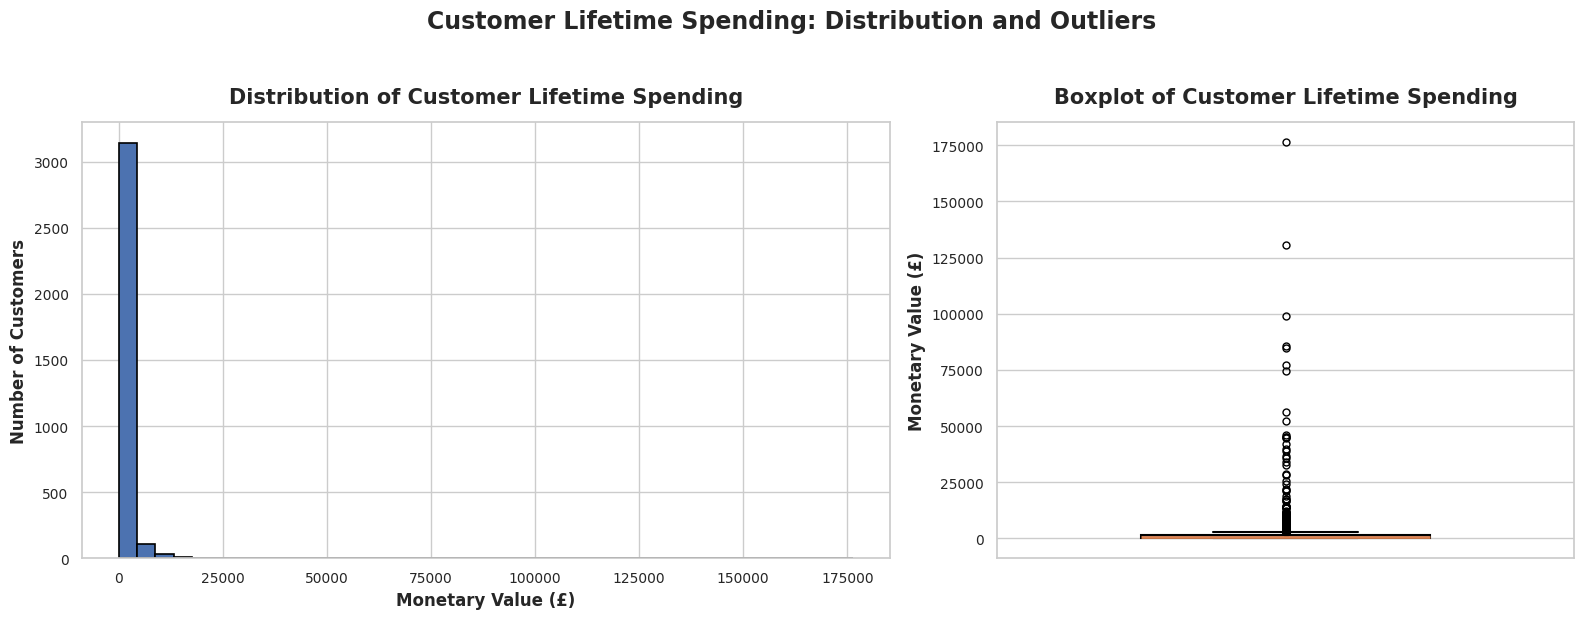

In [40]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    gridspec_kw={"width_ratios": [1.4, 1]}
)

# Histogram
axes[0].hist(
    customer_features["Monetary"],
    bins=40,
    edgecolor="black",
    linewidth=1.2
)

axes[0].set_title(
    "Distribution of Customer Lifetime Spending",
    fontsize=15,
    fontweight="bold",
    pad=14
)
axes[0].set_xlabel("Monetary Value (£)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Number of Customers", fontsize=12, fontweight="bold")
axes[0].tick_params(axis="both", labelsize=10)

# Boxplot
axes[1].boxplot(
    customer_features["Monetary"],
    vert=True,
    patch_artist=True,
    widths=0.5,
    boxprops={"linewidth": 1.5},
    whiskerprops={"linewidth": 1.5},
    capprops={"linewidth": 1.5},
    medianprops={"linewidth": 2},
    flierprops={
        "marker": "o",
        "markersize": 5,
        "markeredgewidth": 1
    }
)

axes[1].set_title(
    "Boxplot of Customer Lifetime Spending",
    fontsize=15,
    fontweight="bold",
    pad=14
)
axes[1].set_ylabel("Monetary Value (£)", fontsize=12, fontweight="bold")
axes[1].tick_params(axis="both", labelsize=10)
axes[1].set_xticks([])

fig.suptitle(
    "Customer Lifetime Spending: Distribution and Outliers",
    fontsize=17,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

In [41]:
customer_features["Monetary"].describe().round(2)

,Monetary
count,3317.00
mean,1575.97
std,5974.01
min,2.90
25%,258.25
50%,552.80
75%,1355.11
max,176355.94


In [42]:
customer_features["Monetary"].skew().round(2)

np.float64(16.27)

### Key Findings & Business Interpretation

- Customer lifetime spending exhibits an extremely right-skewed distribution, with a skewness coefficient of **16.26**.
- The average customer spent **£1,579.51**, while the median customer spent only **£555.65**, indicating that a relatively small number of high-value customers raise the overall average.
- Customer liftetime spending varies considerably, with a standard deviation of **£5,976.60** and individual customer spending ranging from **£2.90** to **£176,355.94**.
- The histogram and boxplot reveal numerous high-spending outliers, suggesting that customer value is concentrated among a relatively small segment of customers.
The retailer's customer base follows a highly unequal spending pattern in which a relatively small proportion of customers generate substantially higher lifetime revenue than the majority of customers. Consequently, the financial impact of losing a high-value customer is likely to be considerably greater than losing a low-value customer.

## Business Interpretation

 These findings highlight the importance of customer segmentation and targeted retention strategies. In the context of churn prediction, accurately identifying high-value customers who are at risk of leaving may deliver greater business value than treating all customers equally.





### Business Question

Is customer spending concentrated among a relatively small proportion of customers?

# Sort customers by lifetime spending


In [43]:
# Sort customers by historical spending
pareto_df = (
    customer_features
    .sort_values(by="Monetary", ascending=False)
    .reset_index(drop=True)
)

pareto_df.head()

,Recency,Frequency,Monetary,AverageBasketValue,AverageQuantityPerInvoice,UniqueInvoices,UniqueProducts,ProductDiversity,CustomerTenure,ActiveMonths,AveragePurchaseInterval,PurchaseRegularity,Country,IsUKCustomer
0,6,40,176355.94,4408.898500,95.790627,40,492,12.300000,254,9,6.051282,8.388428,Netherlands,0
1,27,26,130537.23,5020.662692,188.563291,26,54,2.076923,267,8,10.636364,14.827726,United Kingdom,1
2,14,13,99146.16,7626.627692,108.062606,13,377,29.000000,237,8,19.818182,15.510114,Australia,0
3,9,22,85610.34,3891.379091,173.217391,22,107,4.863636,267,8,12.000000,15.009997,United Kingdom,1
4,15,35,84977.35,2427.924286,38.946257,35,596,17.028571,271,9,7.363636,8.763626,EIRE,0


In [44]:
pareto_df["CumulativeRevenue"] = pareto_df["Monetary"].cumsum()

pareto_df["RevenueShare"] = (
    pareto_df["CumulativeRevenue"]
    / pareto_df["Monetary"].sum()
) * 100

pareto_df["CustomerShare"] = (
    np.arange(1, len(pareto_df)+1)
    / len(pareto_df)
) * 100

### Revenue Concentration Analysis

#### Business Question

How much of the retailer's total customer lifetime revenue is generated by its highest-value customers?

In [45]:
# Percentage of customers to evaluate
customer_percentiles = [1, 5, 10, 20, 30, 50]

total_revenue = pareto_df["Monetary"].sum()

revenue_summary = []

for pct in customer_percentiles:

    n_customers = max(1, int(len(pareto_df) * pct / 100))

    revenue = pareto_df["Monetary"].head(n_customers).sum()

    revenue_summary.append({
        "Top Customer Segment": f"Top {pct}%",
        "Customers": n_customers,
        "Revenue Share (%)": revenue / total_revenue * 100
    })

revenue_summary = pd.DataFrame(revenue_summary)

revenue_summary["Revenue Share (%)"] = (
    revenue_summary["Revenue Share (%)"]
    .round(1)
)

revenue_summary

,Top Customer Segment,Customers,Revenue Share (%)
0,Top 1%,33,29.6
1,Top 5%,165,48.3
2,Top 10%,331,59.5
3,Top 20%,663,73.0
4,Top 30%,995,81.6
5,Top 50%,1658,91.5


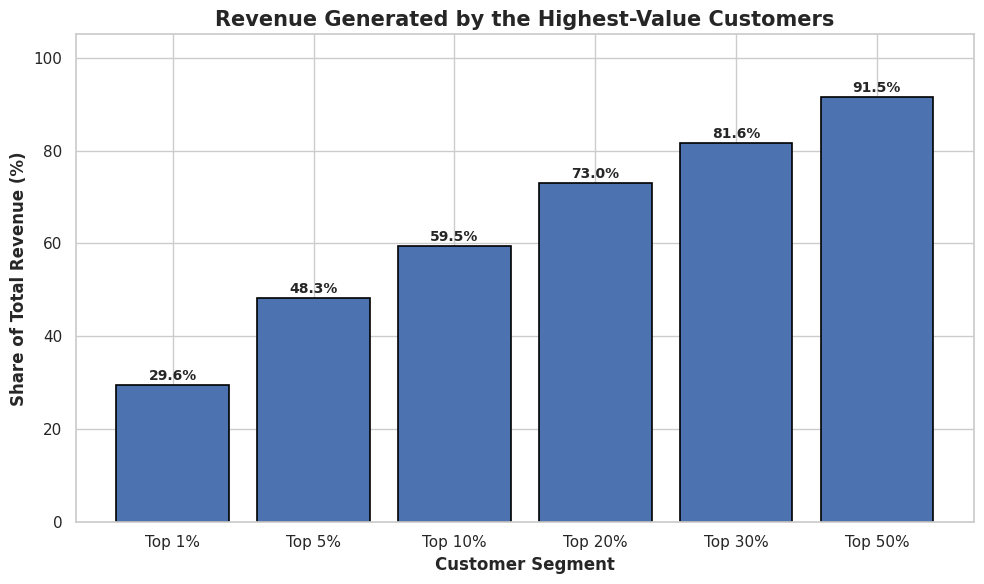

In [46]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    revenue_summary["Top Customer Segment"],
    revenue_summary["Revenue Share (%)"],
    edgecolor="black",
    linewidth=1.2
)

plt.title(
    "Revenue Generated by the Highest-Value Customers",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Customer Segment",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Share of Total Revenue (%)",
    fontsize=12,
    fontweight="bold"
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.ylim(0, 105)

plt.tight_layout()

plt.show()

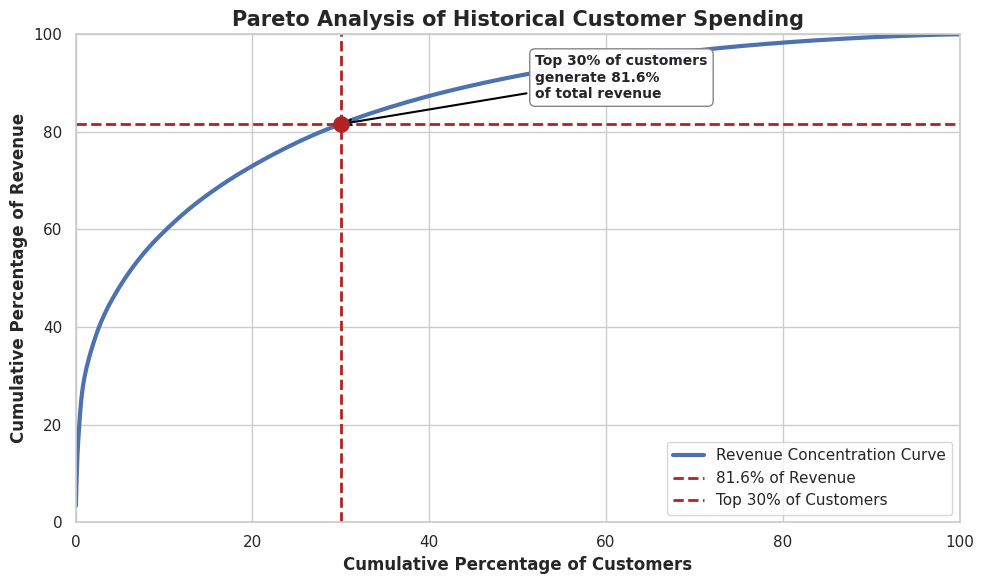

In [47]:
# Pareto Analysis of Historical Customer  Spending

plt.figure(figsize=(10, 6))

# Pareto curve
plt.plot(
    pareto_df["CustomerShare"],
    pareto_df["RevenueShare"],
    linewidth=3,
    label="Revenue Concentration Curve"
)

# Reference lines
plt.axhline(
    y=81.6,
    color="firebrick",
    linestyle="--",
    linewidth=2,
    label="81.6% of Revenue"
)

plt.axvline(
    x=30,
    color="firebrick",
    linestyle="--",
    linewidth=2,
    label="Top 30% of Customers"
)

# Highlight the intersection
plt.scatter(
    30,
    81.6,
    color="firebrick",
    s=120,
    zorder=5
)

# Annotation
plt.annotate(
    "Top 30% of customers\ngenerate 81.6%\nof total revenue",
    xy=(30, 81.6),
    xytext=(52, 87),
    arrowprops=dict(
        arrowstyle="->",
        lw=1.5,
        color="black"
    ),
    fontsize=10,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.4",
        fc="white",
        ec="gray",
        lw=1,
        alpha=0.95
    )
)

# Title
plt.title(
    "Pareto Analysis of Historical Customer Spending",
    fontsize=15,
    fontweight="bold"
)

# Axis labels
plt.xlabel(
    "Cumulative Percentage of Customers",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Cumulative Percentage of Revenue",
    fontsize=12,
    fontweight="bold"
)

# Axis limits
plt.xlim(0, 100)
plt.ylim(0, 100)

# Legend
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

## Understanding Customer Engagement

Customer engagement reflects how recently, how frequently, and over what period customers interact with the retailer. These behavioral patterns provide valuable insight into customer loyalty and purchasing habits, making them particularly relevant for churn prediction.

### Business Question

How engaged are customers with the retailer, and what do their purchasing behaviors reveal about potential churn risk?

### Recency

#### Business Question

How recently have customers made a purchase, and does the customer base include a substantial number of inactive customers?

In [48]:
customer_features["Recency"].describe().round(2)

,Recency
count,3317.00
mean,93.11
std,76.68
min,1.00
25%,28.00
50%,73.00
75%,146.00
max,274.00


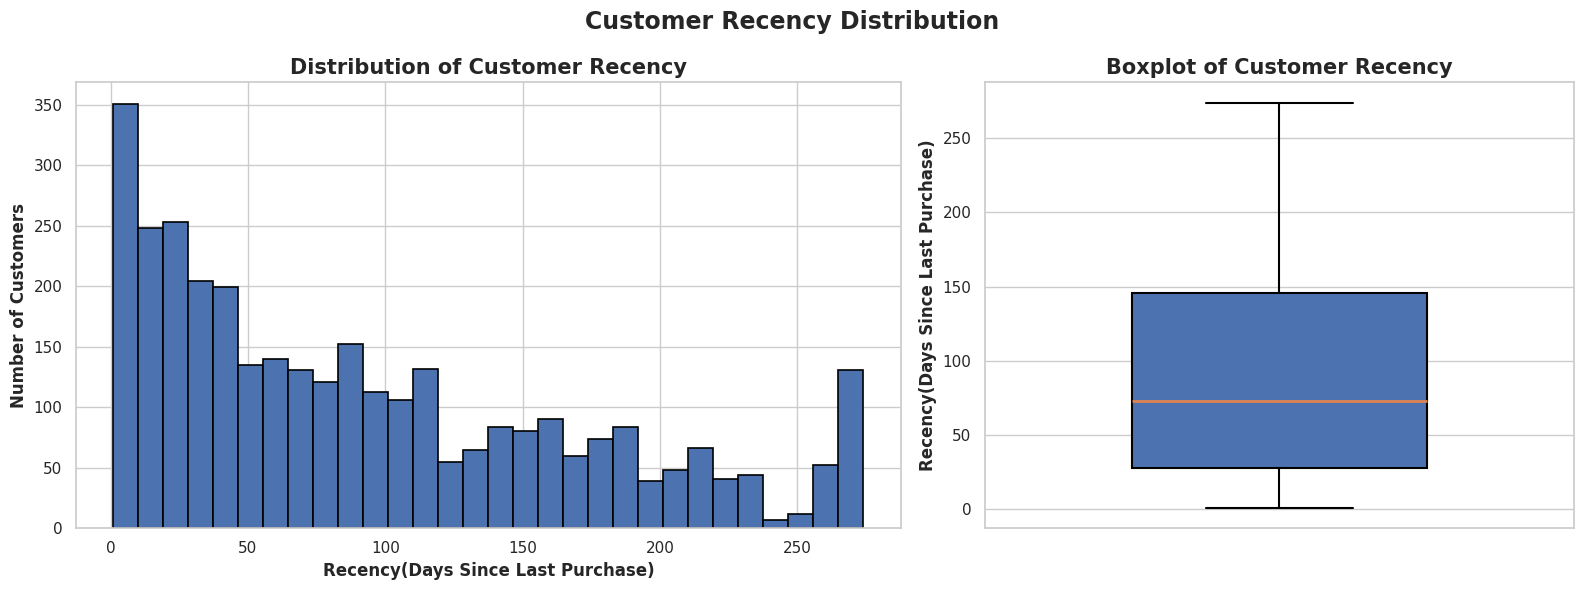

In [49]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    gridspec_kw={"width_ratios": [1.4, 1]}
)

# Histogram
axes[0].hist(
    customer_features["Recency"],
    bins=30,
    edgecolor="black",
    linewidth=1.2
)

axes[0].set_title(
    "Distribution of Customer Recency",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Recency(Days Since Last Purchase)",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_ylabel(
    "Number of Customers",
    fontsize=12,
    fontweight="bold"
)

# Boxplot
axes[1].boxplot(
    customer_features["Recency"],
    patch_artist=True,
    widths=0.5,
    boxprops={"linewidth": 1.5},
    whiskerprops={"linewidth": 1.5},
    capprops={"linewidth": 1.5},
    medianprops={"linewidth": 2},
)

axes[1].set_title(
    "Boxplot of Customer Recency",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_ylabel(
    "Recency(Days Since Last Purchase)",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xticks([])

fig.suptitle(
    "Customer Recency Distribution",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### Key Findings

- Customer recency ranged from **1 to 274 days**, indicating substantial variation in how recently customers made purchases.

- The median recency was **73 days**, meaning that half of all customers made a purchase within approximately two and a half months of the observation period.

- The distribution is **right-skewed**, with the highest concentration of customers having made recent purchases. As recency increases, the number of customers gradually declines, indicating that fewer customers experienced extended periods without making a purchase..

- The wide spread of recency values suggests varying levels of customer engagement across the customer base.                                        







### Business Insight

Recency provides a direct measure of customer engagement by indicating how recently customers interacted with the retailer. Customers with lower recency values are generally more actively engaged, while those with longer periods since their last purchase may represent customers whose engagement has weakened.

The broad range of recency values observed across the customer base suggests meaningful variation in customer activity levels, making Recency a valuable behavioral feature for distinguishing customers who may be at greater risk of churn.

### Customer Tenure

#### Business Question

How long have customers maintained a relationship with the retailer, and what does the distribution of customer tenure reveal about the customer base?

In [50]:
customer_features["CustomerTenure"].describe().round(2)

,CustomerTenure
count,3317.00
mean,175.75
std,77.86
min,0.00
25%,117.00
50%,184.00
75%,257.00
max,273.00


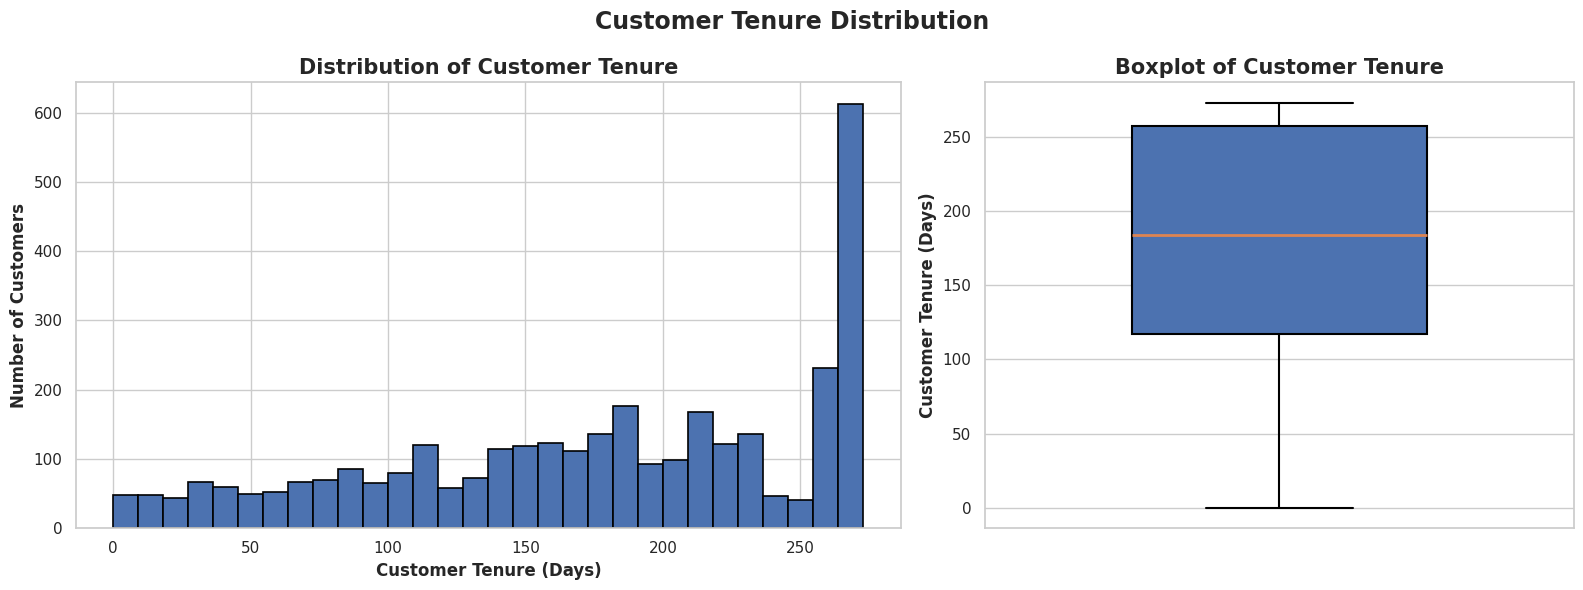

In [51]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16,6),
    gridspec_kw={"width_ratios":[1.4,1]}
)

# Histogram
axes[0].hist(
    customer_features["CustomerTenure"],
    bins=30,
    edgecolor="black",
    linewidth=1.2
)

axes[0].set_title(
    "Distribution of Customer Tenure",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Customer Tenure (Days)",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_ylabel(
    "Number of Customers",
    fontsize=12,
    fontweight="bold"
)

# Boxplot
axes[1].boxplot(
    customer_features["CustomerTenure"],
    patch_artist=True,
    widths=0.5,
    boxprops={"linewidth":1.5},
    whiskerprops={"linewidth":1.5},
    capprops={"linewidth":1.5},
    medianprops={"linewidth":2},
)

axes[1].set_title(
    "Boxplot of Customer Tenure",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_ylabel(
    "Customer Tenure (Days)",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xticks([])

fig.suptitle(
    "Customer Tenure Distribution",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Key Findings

- Customer tenure ranged from **0 to 273 days**, indicating considerable variation in the length of customer relationships.

- The median customer tenure was **184 days**, suggesting that half of all customers had maintained a relationship with the retailer for approximately six months or longer.

- The distribution is **slightly left-skewed**, with a higher concentration of customers exhibiting relatively long tenures and comparatively fewer newly acquired customers.

- The pronounced concentration of customers near the upper end of the tenure distribution suggests that many customers remained active throughout much of the historical observation period.

### Business Insight

Customer tenure reflects the longevity of the relationship between a customer and the retailer. Longer-tenured customers have demonstrated sustained engagement over time, whereas newer customers have had fewer opportunities to establish consistent purchasing behavior.

The predominance of longer-tenured customers suggests that the retailer has retained a substantial base of established customers. As a result, Customer Tenure is likely to provide valuable context when distinguishing between recently acquired customers and long-standing customers in the predictive churn model.

### Active Months

#### Business Question

How consistently have customers remained active throughout their relationship with the retailer, and what does the distribution of active months reveal about customer engagement?

In [52]:
customer_features["ActiveMonths"].describe().round(2)

,ActiveMonths
count,3317.00
mean,2.46
std,1.95
min,1.00
25%,1.00
50%,2.00
75%,3.00
max,9.00


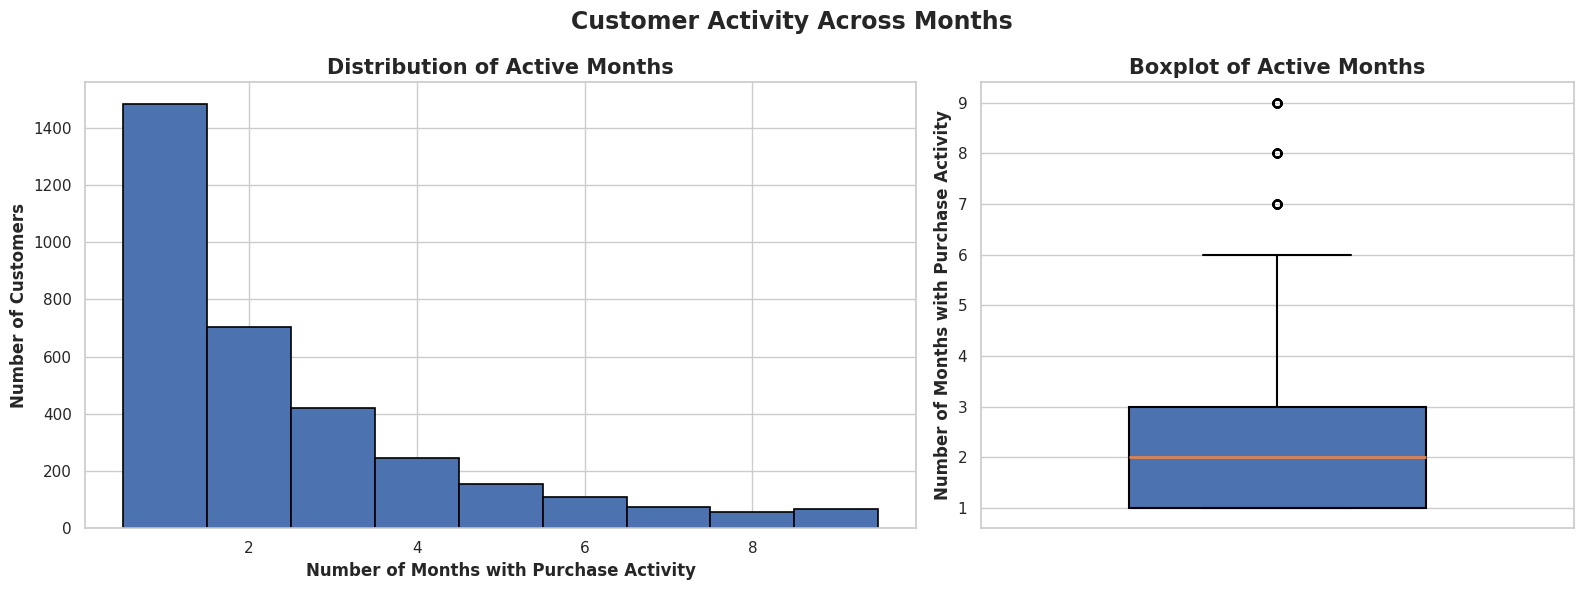

In [53]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    gridspec_kw={"width_ratios": [1.4, 1]}
)

# Histogram
axes[0].hist(
    customer_features["ActiveMonths"],
    bins=np.arange(0.5, 10.5, 1),
    edgecolor="black",
    linewidth=1.2
)

axes[0].set_title(
    "Distribution of Active Months",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Number of Months with Purchase Activity",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_ylabel(
    "Number of Customers",
    fontsize=12,
    fontweight="bold"
)

# Boxplot
axes[1].boxplot(
    customer_features["ActiveMonths"],
    patch_artist=True,
    widths=0.5,
    boxprops={"linewidth":1.5},
    whiskerprops={"linewidth":1.5},
    capprops={"linewidth":1.5},
    medianprops={"linewidth":2},
)

axes[1].set_title(
    "Boxplot of Active Months",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_ylabel(
    "Number of Months with Purchase Activity",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xticks([])

fig.suptitle(
    "Customer Activity Across Months",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Key Findings

- Customers were active for an average of **2.46 months**, with a median of **2 months**, indicating that purchasing activity was generally concentrated within a relatively small number of months.

- The distribution is **positively skewed**, with the majority of customers being active in only one or two months and progressively fewer customers remaining active across additional months.

- While most customers exhibited limited purchasing continuity, a small group of customers remained active across many months, reflecting more consistent purchasing behavior.

### Business Insight

Active Months measures the consistency of customer engagement rather than simply the length of the customer relationship. While Customer Tenure captures how long customers have been associated with the retailer, Active Months indicates how regularly they made purchases during that period.

The predominance of customers active in only a small number of months suggests that many customers purchased intermittently rather than consistently. Conversely, customers with activity spanning multiple months demonstrate stronger and more sustained engagement, making Active Months a valuable behavioral feature for identifying differences in customer loyalty and potential churn risk.

---

The preceding analyses examined customer engagement from three complementary perspectives:

- **Recency** captures how recently customers interacted with the retailer.
- **Customer Tenure** measures the length of the customer relationship.
- **Active Months** reflects the consistency of customer activity over time.

The next analysis focuses on **purchase frequency**, providing an additional perspective on customer engagement by examining how often customers transact with the retailer.

### Purchase Frequency

Business Question

How frequently do customers make purchases, and how regularly do they return to the retailer over time?

In [54]:
customer_features["Frequency"].describe().round(2)

,Frequency
count,3317.00
mean,3.44
std,5.59
min,1.00
25%,1.00
50%,2.00
75%,4.00
max,127.00


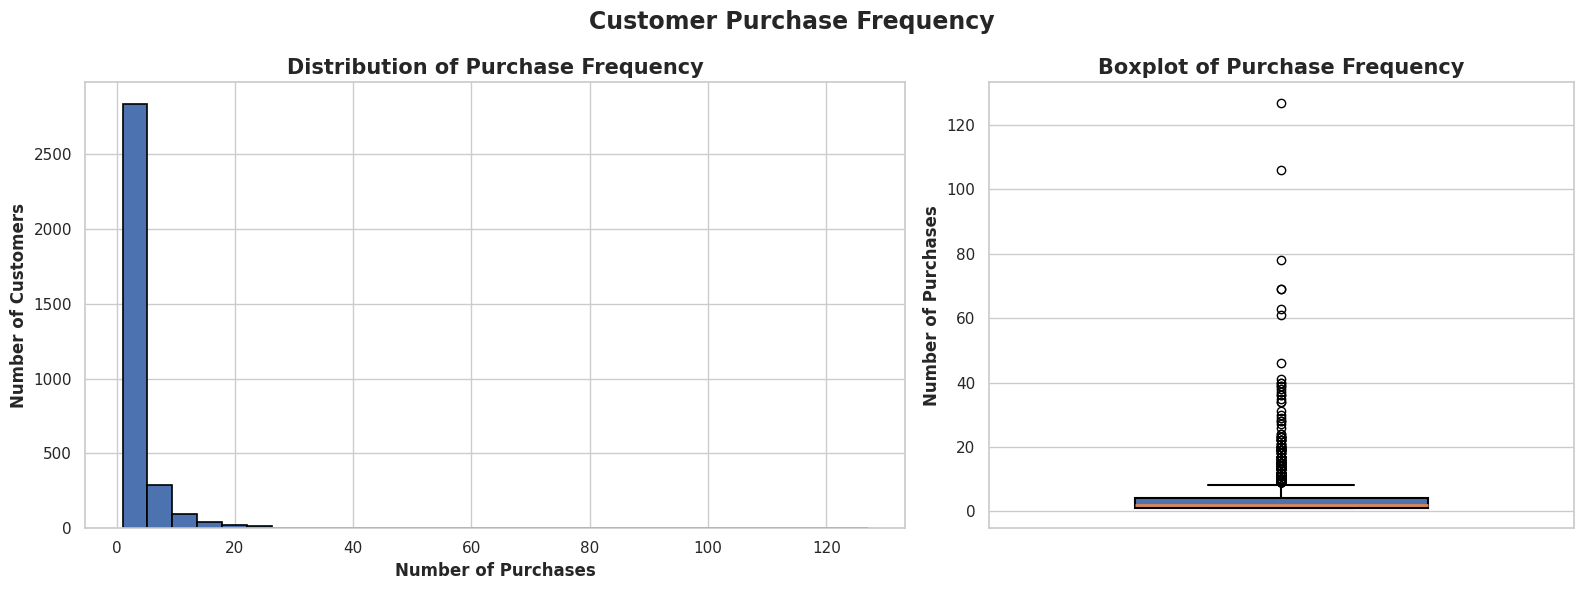

In [55]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16,6),
    gridspec_kw={"width_ratios":[1.4,1]}
)

# Histogram
axes[0].hist(
    customer_features["Frequency"],
    bins=30,
    edgecolor="black",
    linewidth=1.2
)

axes[0].set_title(
    "Distribution of Purchase Frequency",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Number of Purchases",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_ylabel(
    "Number of Customers",
    fontsize=12,
    fontweight="bold"
)

# Boxplot
axes[1].boxplot(
    customer_features["Frequency"],
    patch_artist=True,
    widths=0.5,
    boxprops={"linewidth":1.5},
    whiskerprops={"linewidth":1.5},
    capprops={"linewidth":1.5},
    medianprops={"linewidth":2},
)

axes[1].set_title(
    "Boxplot of Purchase Frequency",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_ylabel(
    "Number of Purchases",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xticks([])

fig.suptitle(
    "Customer Purchase Frequency",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [56]:
customer_features["AveragePurchaseInterval"].describe().round(2)

,AveragePurchaseInterval
count,1943.00
mean,57.63
std,45.36
min,0.00
25%,27.00
50%,45.00
75%,77.00
max,259.00


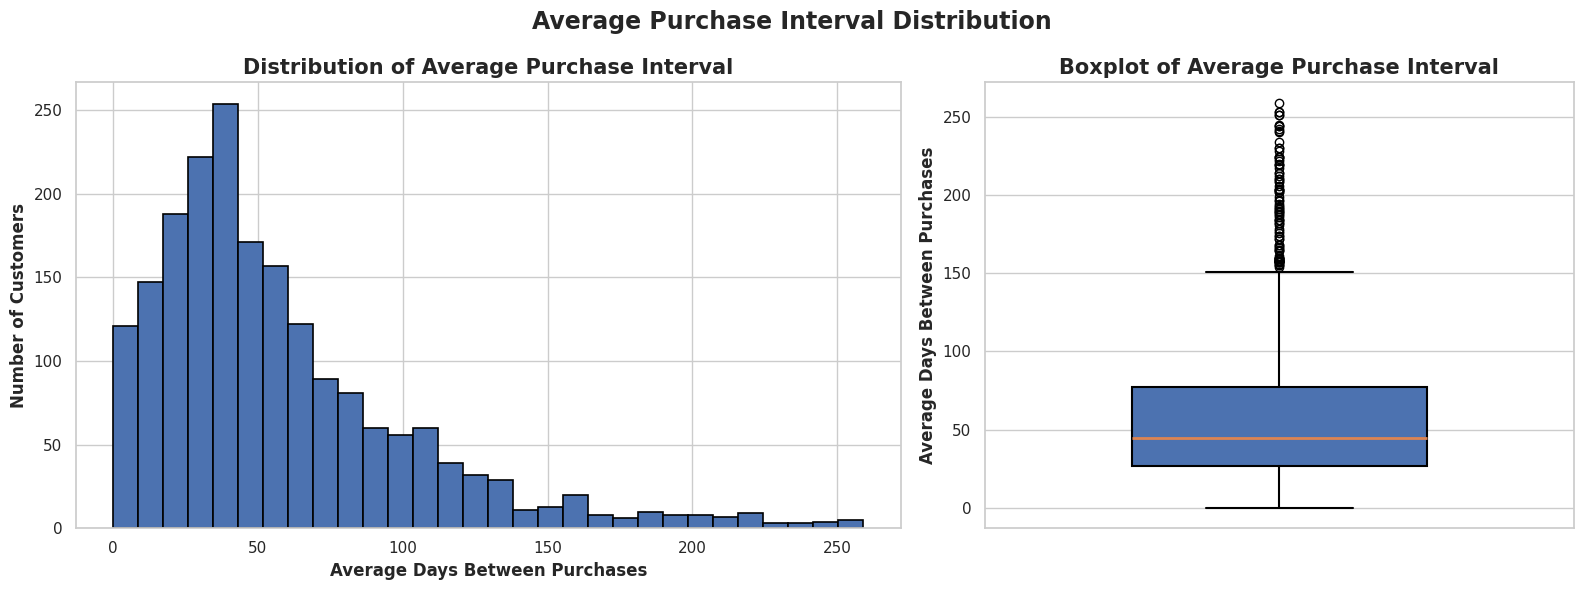

In [57]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    gridspec_kw={"width_ratios": [1.4, 1]}
)

# Histogram
axes[0].hist(
    customer_features["AveragePurchaseInterval"].dropna(),
    bins=30,
    edgecolor="black",
    linewidth=1.2
)

axes[0].set_title(
    "Distribution of Average Purchase Interval",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Average Days Between Purchases",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_ylabel(
    "Number of Customers",
    fontsize=12,
    fontweight="bold"
)

# Boxplot
axes[1].boxplot(
    customer_features["AveragePurchaseInterval"].dropna(),
    patch_artist=True,
    widths=0.5,
    boxprops={"linewidth": 1.5},
    whiskerprops={"linewidth": 1.5},
    capprops={"linewidth": 1.5},
    medianprops={"linewidth": 2},
)

axes[1].set_title(
    "Boxplot of Average Purchase Interval",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_ylabel(
    "Average Days Between Purchases",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xticks([])

fig.suptitle(
    "Average Purchase Interval Distribution",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [58]:
customer_features["AveragePurchaseInterval"].dropna().skew().round(2)

np.float64(1.56)

### Key Findings

- Customers completed an average of **3.44 purchases**, although the median customer made only **2 purchases**, indicating substantial variation in purchasing frequency.

- Purchase Frequency is **highly right-skewed**, with most customers making relatively few purchases and a small group purchasing very frequently.

- Among customers with multiple purchases, the average time between purchases was **57.6 days**, with a median interval of **45 days**.

- The positive skew in Average Purchase Interval indicates that while many repeat customers returned within a relatively short period, a smaller group experienced much longer gaps between purchases.

## Customer Engagement Summary

The customer engagement analysis revealed that engagement is a multidimensional concept that cannot be captured by a single metric alone.

Recency showed that many customers had made relatively recent purchases, indicating ongoing interaction with the retailer. Customer Tenure demonstrated that a substantial portion of the customer base had maintained long-standing relationships with the business. However, Active Months revealed that purchasing activity was often concentrated within only a few months, suggesting that many customers purchased intermittently rather than consistently throughout their tenure. Finally, Purchase Frequency and Average Purchase Interval highlighted considerable variation in both the intensity and regularity of purchasing behavior.


Taken together, these findings show that customer engagement is multidimensional, encompassing the recency of customer interactions, the duration of customer relationships, the consistency of purchasing activity, purchase frequency, and the time between purchases.

## 🛍️ Understanding Shopping Behavior

Customer engagement explains how customers interact with the retailer over time, while shopping behavior describes how customers purchase when they are active. Examining spending patterns, purchase quantities, and product diversity provides additional insight into customer preferences and purchasing habits, helping build a more comprehensive understanding of customer behavior.

### Business Question

How do customers typically shop, and what do their purchasing behaviors reveal about differences in spending habits and buying patterns?

### 💳 Average Basket Value

#### Business Question

How much do customers typically spend during each purchase, and how much variation exists in transaction values across the customer base?

In [59]:
customer_features["AverageBasketValue"].describe().round(2)

,AverageBasketValue
count,3317.00
mean,399.43
std,1435.70
min,2.90
25%,168.20
50%,283.50
75%,412.65
max,77183.60


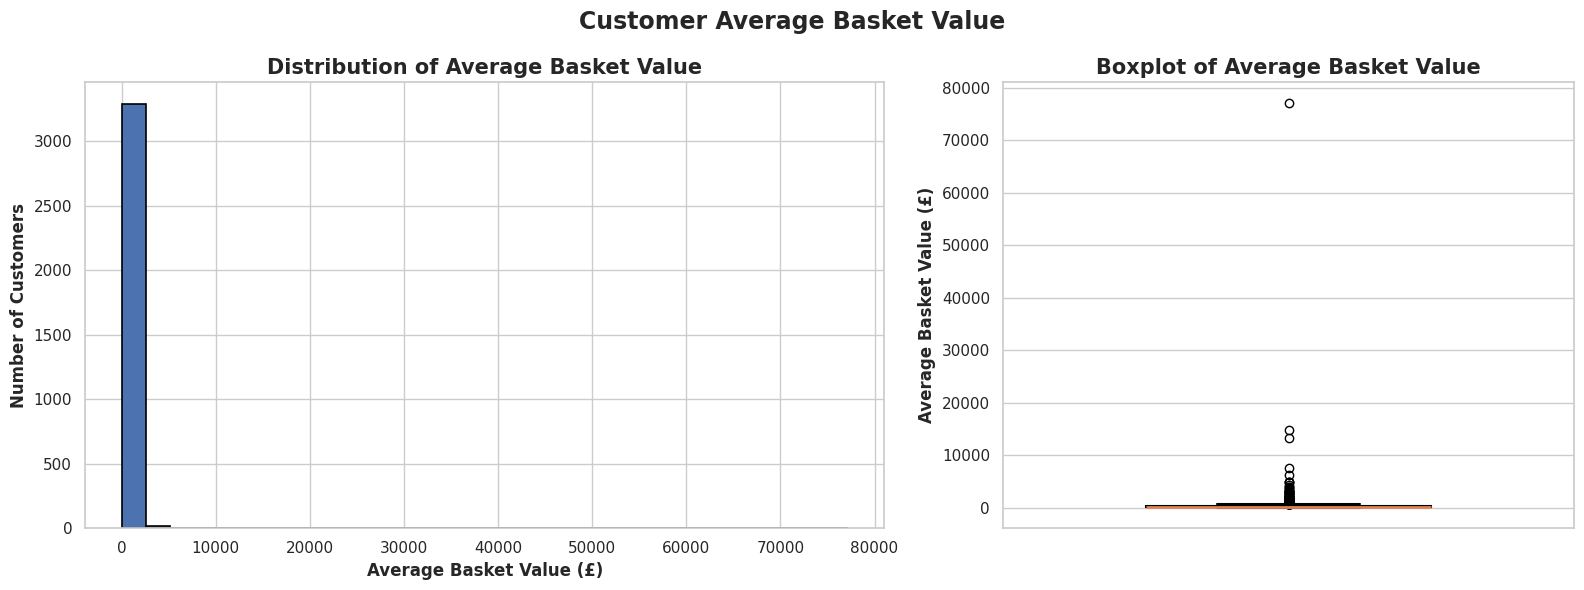

In [60]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    gridspec_kw={"width_ratios": [1.4, 1]}
)

# Histogram
axes[0].hist(
    customer_features["AverageBasketValue"],
    bins=30,
    edgecolor="black",
    linewidth=1.2
)

axes[0].set_title(
    "Distribution of Average Basket Value",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Average Basket Value (£)",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_ylabel(
    "Number of Customers",
    fontsize=12,
    fontweight="bold"
)

# Boxplot
axes[1].boxplot(
    customer_features["AverageBasketValue"],
    patch_artist=True,
    widths=0.5,
    boxprops={"linewidth":1.5},
    whiskerprops={"linewidth":1.5},
    capprops={"linewidth":1.5},
    medianprops={"linewidth":2},
)

axes[1].set_title(
    "Boxplot of Average Basket Value",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_ylabel(
    "Average Basket Value (£)",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xticks([])

fig.suptitle(
    "Customer Average Basket Value",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [61]:
customer_features["AverageBasketValue"].skew().round(2)

np.float64(46.83)

### Key Findings

- Customers spent an average of **£400.53** per transaction, while the median basket value was **£284.55**, indicating a highly right-skewed spending distribution.

- Average Basket Value exhibited **extreme positive skewness (46.83)**, driven by a very small number of exceptionally large transactions.

- Although most customers had relatively modest average basket values, a handful of customers recorded extraordinarily high transaction values, with the maximum exceeding **£77,000**.

- The substantial difference between the mean and median suggests that average transaction spending is heavily influenced by a small number of high-value customers.

### Business Insight

Average Basket Value captures customers' typical spending per transaction rather than their total lifetime value. The extreme right-skewed distribution indicates that while most customers make purchases of relatively modest value, a very small number of customers consistently place exceptionally high-value orders.

This finding suggests that differences in customer value may arise from both **how much customers spend per transaction** and **how frequently they purchase**. Consequently, Average Basket Value complements Purchase Frequency by providing an additional dimension of customer purchasing behavior that may improve churn prediction.

In [62]:
basket_99 = customer_features["AverageBasketValue"].quantile(0.99)

print(f"99th Percentile: £{basket_99:.2f}")

99th Percentile: £2040.18


#### Typical Customer View

The previous visualization illustrates the complete distribution of Average Basket Value, including all observations. However, a very small number of exceptionally large basket values compress the majority of customers into a narrow range, making the overall distribution difficult to interpret.

To better understand the purchasing behavior of the vast majority of customers, the following visualization displays Average Basket Value up to the 99th percentile. The original distribution is retained above to preserve transparency, while this view provides greater insight into typical customer spending patterns.

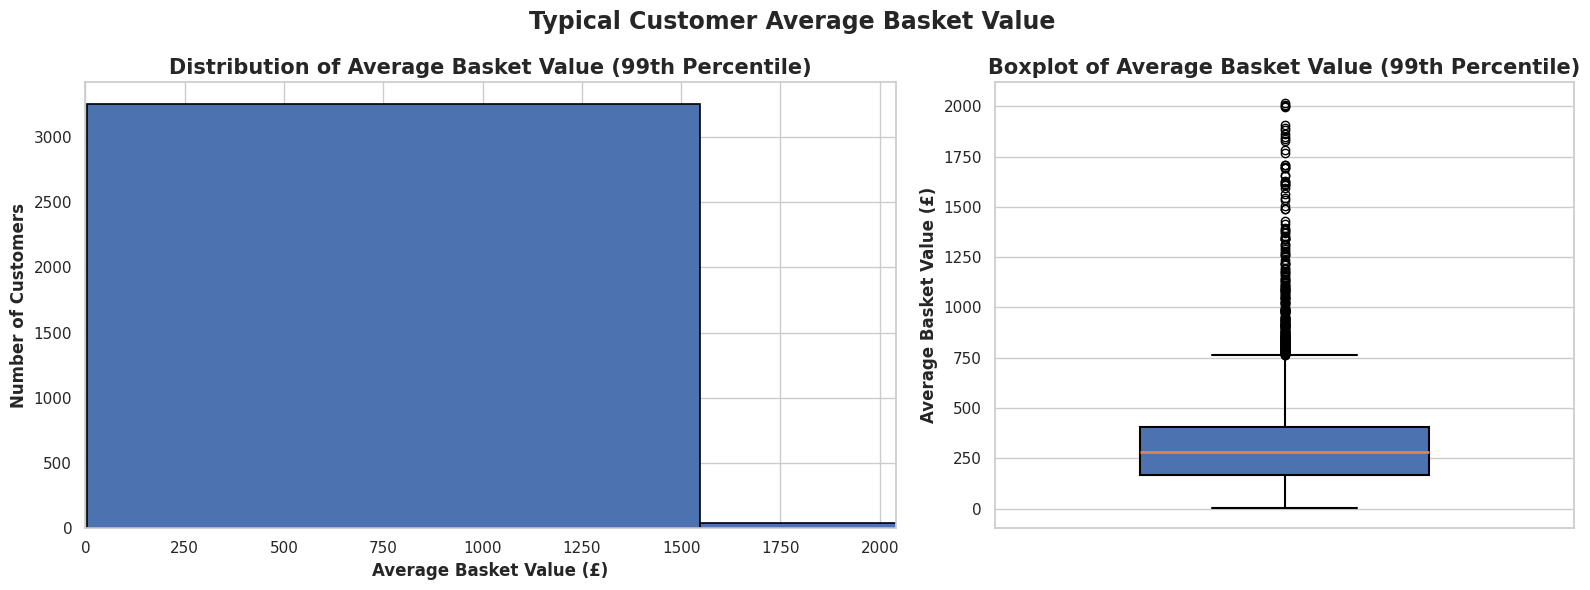

In [63]:
basket_99 = customer_features["AverageBasketValue"].quantile(0.99)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    gridspec_kw={"width_ratios": [1.4, 1]}
)

# Histogram
axes[0].hist(
    customer_features["AverageBasketValue"],
    bins=50,
    edgecolor="black",
    linewidth=1.2
)

axes[0].set_xlim(0, basket_99)

axes[0].set_title(
    "Distribution of Average Basket Value (99th Percentile)",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Average Basket Value (£)",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_ylabel(
    "Number of Customers",
    fontsize=12,
    fontweight="bold"
)

# Boxplot
axes[1].boxplot(
    customer_features.loc[
        customer_features["AverageBasketValue"] <= basket_99,
        "AverageBasketValue"
    ],
    patch_artist=True,
    widths=0.5,
    boxprops={"linewidth": 1.5},
    whiskerprops={"linewidth": 1.5},
    capprops={"linewidth": 1.5},
    medianprops={"linewidth": 2},
)

axes[1].set_title(
    "Boxplot of Average Basket Value (99th Percentile)",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_ylabel(
    "Average Basket Value (£)",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xticks([])

fig.suptitle(
    "Typical Customer Average Basket Value",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [64]:
# Create spending bands
basket_bins = [0, 100, 250, 500, 1000, float("inf")]

basket_labels = [
    "£0–100",
    "£100–250",
    "£250–500",
    "£500–1000",
    "£1000+"
]

customer_features["BasketValueBand"] = pd.cut(
    customer_features["AverageBasketValue"],
    bins=basket_bins,
    labels=basket_labels,
    include_lowest=True
)

band_counts = (
    customer_features["BasketValueBand"]
    .value_counts()
    .sort_index()
)

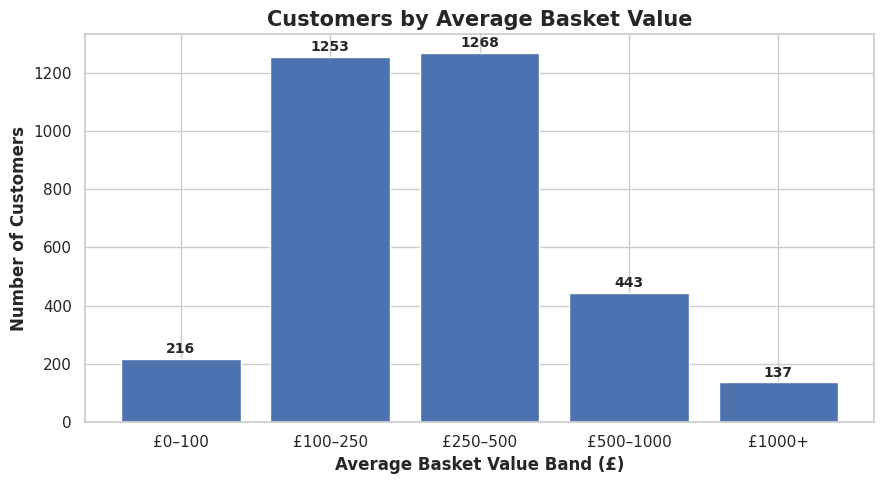

In [65]:
plt.figure(figsize=(9,5))

bars = plt.bar(
    band_counts.index.astype(str),
    band_counts.values
)

# Add labels above bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f"{int(bar.get_height())}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Customers by Average Basket Value",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Average Basket Value Band (£)",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Customers",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [66]:
customer_product_diversity = (
    df.groupby("CustomerID")["StockCode"]
      .nunique()
)

In [67]:
customer_product_diversity.describe()

,StockCode
count,4338.000000
mean,61.501153
std,85.366768
min,1.000000
25%,16.000000
50%,35.000000
75%,77.000000
max,1787.000000


In [68]:
customer_product_diversity.skew()

np.float64(6.919445162710551)

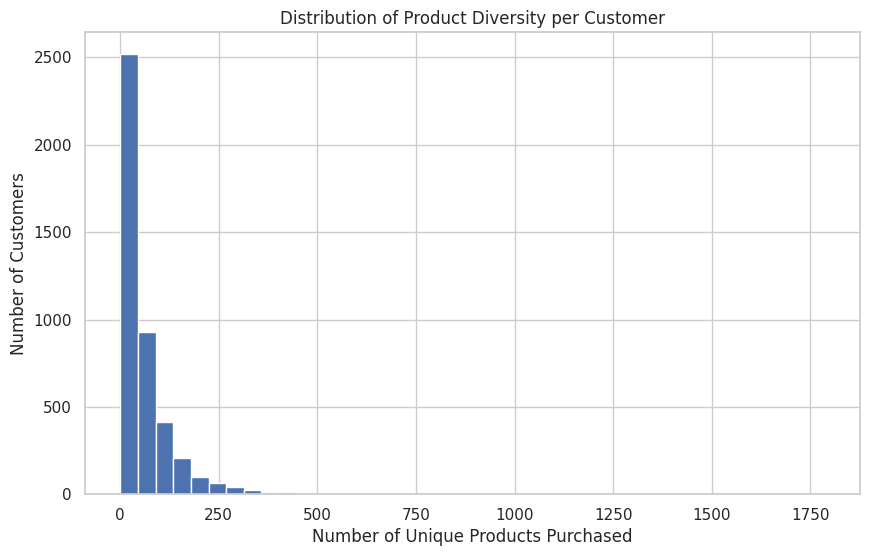

In [69]:
plt.figure(figsize=(10,6))

plt.hist(customer_product_diversity, bins=40)

plt.title("Distribution of Product Diversity per Customer")
plt.xlabel("Number of Unique Products Purchased")
plt.ylabel("Number of Customers")

plt.show()

In [70]:
product_diversity_95 = customer_product_diversity.quantile(0.95)
product_diversity_99 = customer_product_diversity.quantile(0.99)

print(product_diversity_95)
print(product_diversity_99)

205.0
354.0


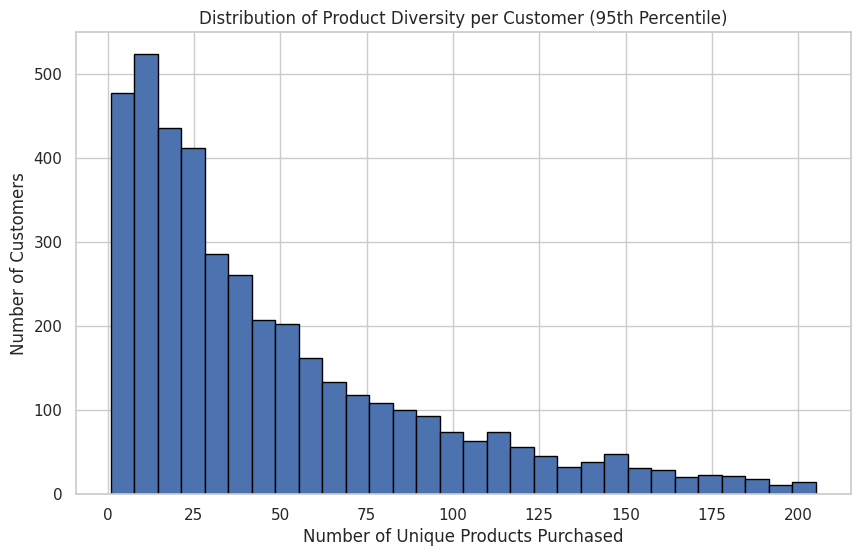

In [71]:
plt.figure(figsize=(10,6))

plt.hist(
    customer_product_diversity[
        customer_product_diversity <= product_diversity_95
    ],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Product Diversity per Customer (95th Percentile)")
plt.xlabel("Number of Unique Products Purchased")
plt.ylabel("Number of Customers")

plt.show()

In [72]:
customer_features["AverageQuantityPerInvoice"].describe()

,AverageQuantityPerInvoice
count,3317.000000
mean,45.630382
std,1295.028486
min,1.000000
25%,5.937500
50%,9.705882
75%,14.545455
max,74215.000000


In [73]:
customer_features["AverageQuantityPerInvoice"].skew()

np.float64(56.71052690804875)

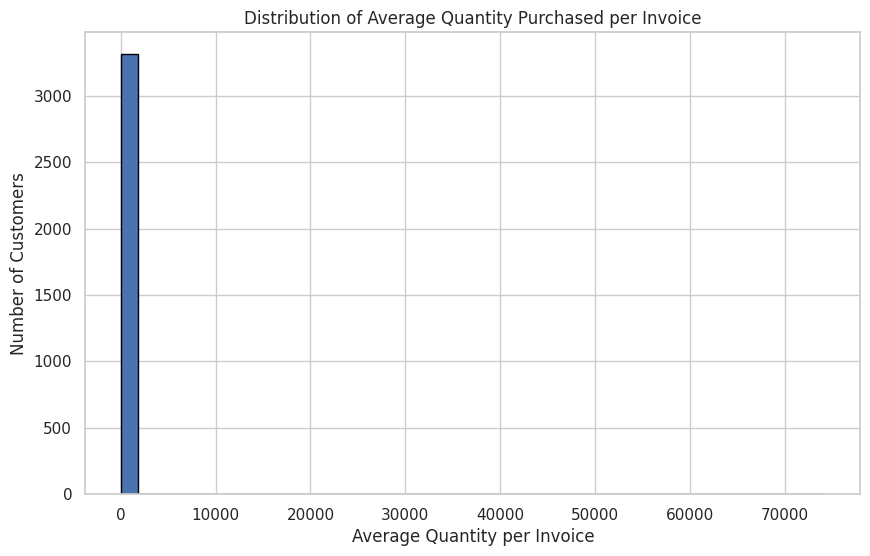

In [74]:
plt.figure(figsize=(10,6))

plt.hist(
    customer_features["AverageQuantityPerInvoice"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Average Quantity Purchased per Invoice")
plt.xlabel("Average Quantity per Invoice")
plt.ylabel("Number of Customers")

plt.show()

In [75]:
quantity_95 = customer_features["AverageQuantityPerInvoice"].quantile(0.95)
quantity_99 = customer_features["AverageQuantityPerInvoice"].quantile(0.99)

print(quantity_95)
print(quantity_99)

51.82780269058292
217.84533333333408


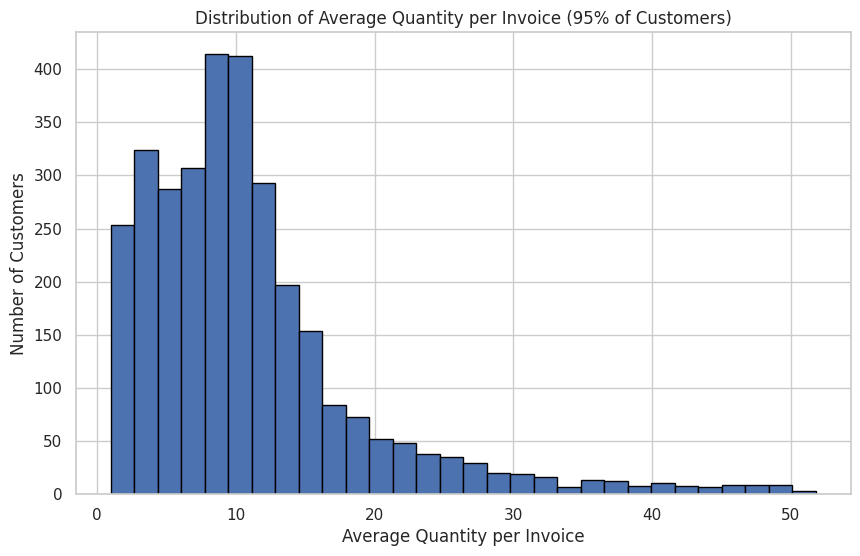

In [76]:
plt.figure(figsize=(10,6))

plt.hist(
    customer_features.loc[
        customer_features["AverageQuantityPerInvoice"] <= quantity_95,
        "AverageQuantityPerInvoice"
    ],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Average Quantity per Invoice (95% of Customers)")
plt.xlabel("Average Quantity per Invoice")
plt.ylabel("Number of Customers")

plt.show()

### Key Findings
-Customers purchased an average of **45.6**  items per invoice, while the median customer purchased only **9.7**, indicating that a relatively small number of exceptionally large orders substantially increased the overall average.
-Average quantity per invoice is extremely right-skewed (skewness = **56.7**).
**95%** of customers averaged approximately **52** items or fewer per invoice, while a very small number averaged substantially larger quantities.
-The visualization focuses on the **95th** percentile to better represent the purchasing behavior of the vast majority of customers, since a handful of exceptionally large orders compress the full distribution.

### Business Insight

Most customers purchase relatively modest quantities per order, while a small group places substantially larger orders. These high-volume purchasers may represent a distinct customer segment with different purchasing behaviors, suggesting opportunities for differentiated inventory planning, pricing strategies, or customer segmentation.

> ### Methodological Note
>
> Initial exploration revealed an extremely right-skewed distribution (skewness = 56.71), making the full histogram difficult to interpret. Rather than removing observations or ignoring the long-tailed nature of the data, a 95th-percentile view was used to better represent the purchasing behavior of the vast majority of customers while preserving the integrity of the complete dataset.

# Customer Churn Behavior

# Time-Based Churn Framework

### Business Objective

To develop a realistic customer churn prediction model, the dataset is divided into historical and future observation periods using a cutoff date.

Customer purchasing behavior before the cutoff date is used to engineer predictive features, while purchasing activity after the cutoff date determines whether a customer churned.

This temporal approach mirrors real-world business scenarios by ensuring that only historical information is used to predict future customer inactivity, thereby preventing target leakage and improving the reliability of the predictive model.

## Monthly Transaction Analysis

### Business Question

How are transactions distributed over time, and where should the dataset be split into historical and future periods for churn prediction?

In [77]:
# Monthly transaction counts
df.set_index('InvoiceDate').resample('ME').size()

,0
InvoiceDate,
2010-12-31,25670
2011-01-31,20988
2011-02-28,19706
2011-03-31,26870
2011-04-30,22433
2011-05-31,28073
2011-06-30,26926
2011-07-31,26580
2011-08-31,26790


## Historical RFM Feature Construction

### Business Objective

Construct customer-level Recency, Frequency, and Monetary (RFM) features using only historical transaction data available before the cutoff date. These features represent the information that would realistically be available when predicting future customer churn.

In [78]:
# Reference date for recency calculation
reference_date = pd.to_datetime(cutoff_date)

In [79]:
# Create historical RFM features
historical_rfm = historical_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

# Rename columns
historical_rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Reset index
historical_rfm = historical_rfm.reset_index()

In [80]:
historical_rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,225,1,77183.60
1,12347.0,29,5,2790.86
2,12348.0,148,3,1487.24
3,12350.0,210,1,334.40
4,12352.0,162,5,1561.81


## Future Purchase Activity and Churn Labeling

### Business Objective

Create the target variable for supervised learning by evaluating customer purchasing behavior during the future observation period.

Customers who made at least one purchase after the cutoff date are classified as active, while customers with no future purchases are labeled as churned.

This approach enables historical customer behavior to be used to predict future inactivity, closely reflecting how churn prediction models are deployed in practice.

In [81]:
# Customers with future purchases
future_customers = future_df['CustomerID'].unique()

In [82]:
# Create churn labels
historical_rfm['Churn'] = ~historical_rfm['CustomerID'].isin(future_customers)

# Convert boolean values to integers
historical_rfm['Churn'] = historical_rfm['Churn'].astype(int)

In [83]:
historical_rfm.head()

,CustomerID,Recency,Frequency,Monetary,Churn
0,12346.0,225,1,77183.60,1
1,12347.0,29,5,2790.86,0
2,12348.0,148,3,1487.24,0
3,12350.0,210,1,334.40,1
4,12352.0,162,5,1561.81,0


### Churn Distribution



### Business Question

What proportion of customers churned, and is customer churn a relatively common or rare event in the dataset?

,Count,Percentage
ChurnLabel,,
Active,1952,58.8
Churned,1365,41.2


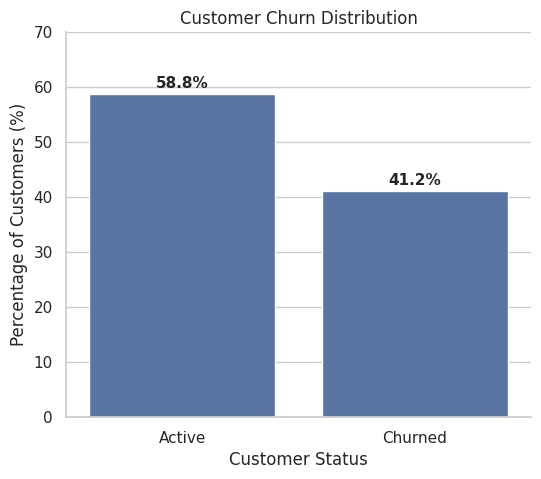

In [84]:


# Create descriptive labels for visualization
historical_rfm['ChurnLabel'] = historical_rfm['Churn'].map({
    0: 'Active',
    1: 'Churned'
})

# Calculate churn counts and percentages
churn_counts = historical_rfm['ChurnLabel'].value_counts().reindex(['Active', 'Churned'])
churn_percent = (
    historical_rfm['ChurnLabel']
    .value_counts(normalize=True)
    .reindex(['Active', 'Churned']) * 100
).round(1)

# Display summary table
churn_summary = pd.DataFrame({
    'Count': churn_counts,
    'Percentage': churn_percent
})

display(churn_summary)

# Plot churn distribution
plt.figure(figsize=(6, 5))

ax = sns.barplot(
    x=churn_percent.index,
    y=churn_percent.values
)

plt.title('Customer Churn Distribution')
plt.xlabel('Customer Status')
plt.ylabel('Percentage of Customers (%)')

# Add percentage labels above bars
for i, value in enumerate(churn_percent.values):
    ax.text(
    i,
    value + 1,
    f'{value:.1f}%',
    ha='center',
    fontsize=11,
    fontweight='bold'
)

plt.ylim(0, 70)

sns.despine()

plt.show()

## Recency vs Customer Status

### Business Question

How does customer recency differ between active and churned customers, and does recent purchasing behavior provide an early indication of future churn?

,Customer_Count,Mean_Recency,Median_Recency,Standard_Deviation,Minimum_Recency,Maximum_Recency
ChurnLabel,,,,,,
Active,1952,72.37,48.0,68.59,0,273
Churned,1365,120.42,113.0,78.79,0,273


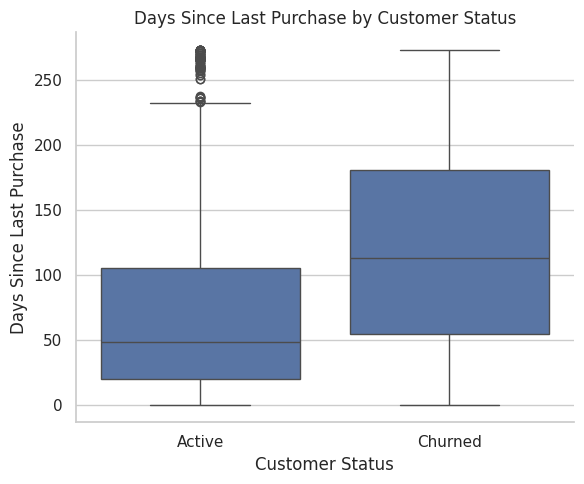

In [85]:


# Calculate summary statistics by customer status
recency_summary = (
    historical_rfm
    .groupby('ChurnLabel')['Recency']
    .agg(
        Customer_Count='count',
        Mean_Recency='mean',
        Median_Recency='median',
        Standard_Deviation='std',
        Minimum_Recency='min',
        Maximum_Recency='max'
    )
    .round(2)
    .reindex(['Active', 'Churned'])
)

display(recency_summary)

# Visualize recency distribution by customer status
plt.figure(figsize=(6, 5))

sns.boxplot(
    x='ChurnLabel',
    y='Recency',
    data=historical_rfm,
    order=['Active', 'Churned']
)

plt.title('Days Since Last Purchase by Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Days Since Last Purchase')

sns.despine()
plt.tight_layout()
plt.show()

### Key Findings

- Churned customers exhibit noticeably higher recency values than active customers, indicating that they had gone longer without making a purchase before the prediction cutoff date.

- Active customers generally made purchases more recently, with a substantially lower median recency and a more concentrated distribution.

- Although the distributions overlap, the overall separation between the two groups suggests that longer periods of purchasing inactivity are associated with a greater likelihood of future churn.

### Business Insight

Recency appears to be an important behavioral indicator of future churn. Customers who have not made a purchase for an extended period are more likely to become inactive during the future observation window.

This suggests that businesses can use recency as an early warning signal to identify at-risk customers and initiate targeted retention campaigns before those customers disengage completely.

### Methodological Note

Recency was calculated using only transactions from the historical observation period before the prediction cutoff date. This prevents future information from influencing the feature and ensures that the analysis reflects information that would have been available when making a real-world churn prediction.

## Frequency vs Customer Status

### Business Question

How does purchase frequency differ between active and churned customers, and does purchasing frequency provide insight into future customer retention?

,Customer_Count,Mean_Frequency,Median_Frequency,Standard_Deviation,Minimum_Frequency,Maximum_Frequency
ChurnLabel,,,,,,
Active,1952,4.59,3.0,6.93,1,127
Churned,1365,1.80,1.0,1.64,1,34


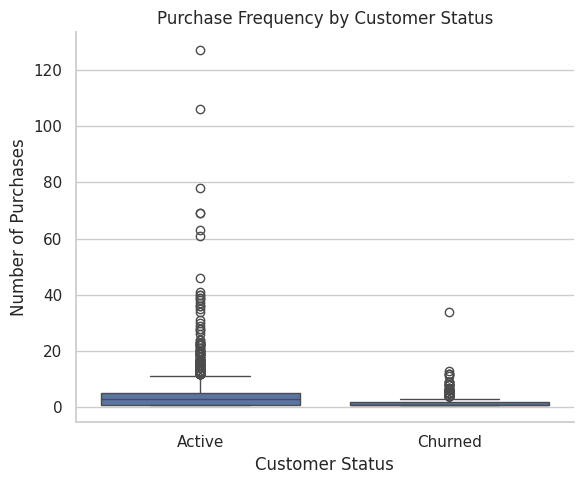

In [86]:


# Calculate summary statistics by customer status
frequency_summary = (
    historical_rfm
    .groupby('ChurnLabel')['Frequency']
    .agg(
        Customer_Count='count',
        Mean_Frequency='mean',
        Median_Frequency='median',
        Standard_Deviation='std',
        Minimum_Frequency='min',
        Maximum_Frequency='max'
    )
    .round(2)
    .reindex(['Active', 'Churned'])
)

display(frequency_summary)

# Visualize purchase frequency by customer status
plt.figure(figsize=(6, 5))

sns.boxplot(
    x='ChurnLabel',
    y='Frequency',
    data=historical_rfm,
    order=['Active', 'Churned']
)

plt.title('Purchase Frequency by Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Number of Purchases')

sns.despine()
plt.tight_layout()
plt.show()

### Key Findings

- Active customers generally made purchases more frequently during the historical observation period than customers who later churned.

- Churned customers exhibited lower purchase frequencies, suggesting weaker engagement before the prediction cutoff date.

- Although a small number of highly active customers created several high-frequency outliers, the overall distribution indicates that customers who purchase more frequently are more likely to remain active.

### Business Insight

Purchase frequency serves as an important indicator of customer engagement and loyalty. Customers who make purchases more frequently are generally more likely to remain active, while declining purchase frequency may signal increasing disengagement.

Businesses can monitor changes in purchase frequency to identify customers whose engagement is weakening and proactively implement retention strategies before they stop purchasing altogether.

### Methodological Note

Purchase frequency was calculated using transactions from the historical observation period before the prediction cutoff date. Restricting the calculation to historical data prevents data leakage and ensures that the feature reflects customer purchasing behavior that would have been available at the time of prediction.

## Monetary vs Customer Status

### Business Question

How does customer spending differ between active and churned customers, and is monetary value alone a strong indicator of future customer retention?

,Customer_Count,Mean_Monetary,Median_Monetary,Standard_Deviation,Minimum_Monetary,Maximum_Monetary
ChurnLabel,,,,,,
Active,1952,2188.00,846.77,7383.00,2.90,176355.94
Churned,1365,700.73,335.52,2737.38,3.75,77183.60


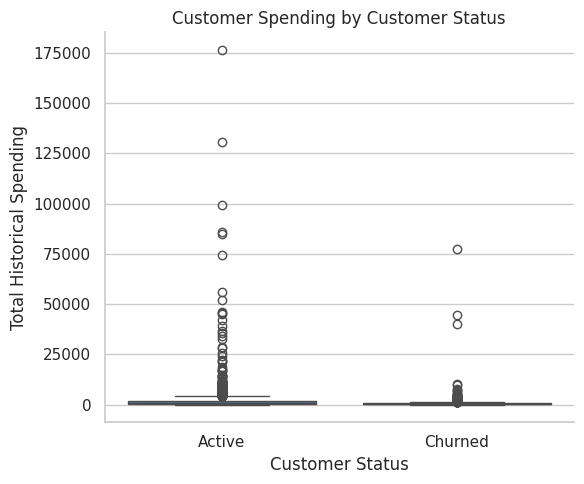

In [87]:


# Calculate summary statistics by customer status
monetary_summary = (
    historical_rfm
    .groupby('ChurnLabel')['Monetary']
    .agg(
        Customer_Count='count',
        Mean_Monetary='mean',
        Median_Monetary='median',
        Standard_Deviation='std',
        Minimum_Monetary='min',
        Maximum_Monetary='max'
    )
    .round(2)
    .reindex(['Active', 'Churned'])
)

display(monetary_summary)

# Visualize monetary value by customer status
plt.figure(figsize=(6, 5))

sns.boxplot(
    x='ChurnLabel',
    y='Monetary',
    data=historical_rfm,
    order=['Active', 'Churned']
)

plt.title('Customer Spending by Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Total Historical Spending')

sns.despine()
plt.tight_layout()
plt.show()

### Key Findings

- Active customers generally exhibit higher historical spending than customers who later churned, although the difference between the two groups is less pronounced than that observed for recency and purchase frequency.

- Both active and churned customers include several high-value outliers, indicating that customers with substantial historical spending are not immune to churn.

- The considerable overlap in spending distributions suggests that monetary value alone provides a weaker distinction between active and churned customers than recency or frequency.

### Business Insight

Historical spending provides valuable context about customer value, but it should not be viewed as a standalone indicator of customer retention. Some high-value customers still became inactive during the future observation period, demonstrating that spending alone does not guarantee continued engagement.

This finding highlights the importance of evaluating customer value alongside behavioral measures such as recency and purchase frequency. Combining these complementary features enables businesses to identify not only their highest-value customers, but also those whose purchasing behavior indicates an increased risk of churn.

### Methodological Note

Monetary value represents the total spending accumulated during the historical observation period before the prediction cutoff date. Restricting the calculation to historical transactions prevents data leakage and ensures that the feature reflects customer value known at the time the churn prediction would have been made.

### Create Behavioral Analysis Dataset

The engineered customer features are combined with the churn labels to create a single dataset for validating behavioral features prior to predictive modeling.

In [88]:
# Create behavioral analysis dataset by adding churn labels
behavioral_features = (
    customer_features
    .reset_index()
    .merge(
        historical_rfm[['CustomerID', 'ChurnLabel']],
        on='CustomerID',
        how='left'
    )
)

# Verify the result
behavioral_features.head()

,CustomerID,Recency,Frequency,Monetary,AverageBasketValue,AverageQuantityPerInvoice,UniqueInvoices,UniqueProducts,ProductDiversity,CustomerTenure,ActiveMonths,AveragePurchaseInterval,PurchaseRegularity,Country,IsUKCustomer,BasketValueBand,ChurnLabel
0,17850.0,273,34,5391.21,158.565000,5.835017,34,21,0.617647,273,1,0.000000,0.000000,United Kingdom,1,£100–250,Churned
1,13047.0,27,8,2682.01,335.251250,8.314286,8,84,10.500000,273,6,40.833333,22.283776,United Kingdom,1,£250–500,Active
2,12583.0,7,9,4232.21,470.245556,23.719178,9,84,9.333333,273,8,33.000000,20.078418,France,0,£250–500,Active
3,13748.0,133,3,580.85,193.616667,17.153846,3,11,3.666667,273,2,70.500000,79.903066,United Kingdom,1,£100–250,Active
4,15100.0,234,3,876.00,292.000000,26.666667,3,1,0.333333,273,2,19.500000,17.677670,United Kingdom,1,£250–500,Churned


## Additional Behavioral Feature Validation

While the traditional RFM metrics capture core aspects of customer behavior, additional behavioral features were engineered to provide deeper insights into customer relationship history, engagement patterns, spending behavior, and purchasing breadth.

These analyses help validate whether the engineered features capture meaningful behavioral differences between active and churned customers before they are incorporated into predictive models.

### Customer Tenure

#### Business Question

Do active and churned customers differ in the length of their relationship with the business, and does customer tenure appear to be associated with customer retention?

,count,mean,std,min,25%,50%,75%,max
ChurnLabel,,,,,,,,
Active,1952.0,184.72,77.38,0.0,133.0,197.5,260.0,273.0
Churned,1365.0,162.91,76.78,0.0,105.0,167.0,225.0,273.0


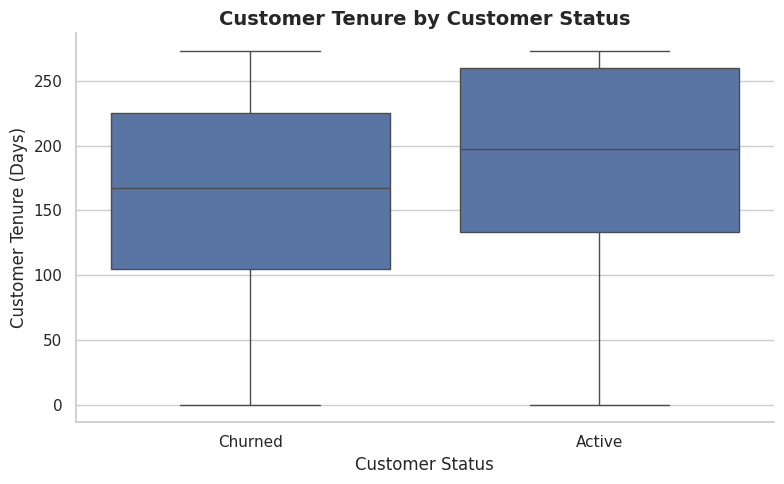

In [89]:
# Summary statistics by customer status
tenure_summary = (
    behavioral_features
    .groupby('ChurnLabel')['CustomerTenure']
    .describe()
    .round(2)
)

display(tenure_summary)

# Visualization
plt.figure(figsize=(8,5))

sns.boxplot(
    data=behavioral_features,
    x='ChurnLabel',
    y='CustomerTenure'
)

plt.title(
    'Customer Tenure by Customer Status',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Customer Status')
plt.ylabel('Customer Tenure (Days)')

sns.despine()
plt.tight_layout()
plt.show()

#### Key Findings
- Active customers had a longer median customer tenure than churned customers.
- The overall distribution of customer tenure was shifted toward longer relationships for active customers, suggesting that customers with more established relationships were more likely to remain active.
- Although the two groups exhibited considerable overlap, customer tenure appears to be positively associated with customer retention.

#### Business Insight

Customer tenure reflects the maturity of a customer's relationship with the business. The longer tenure observed among active customers suggests that customers who remain engaged over time are more likely to continue purchasing. This highlights the importance of early retention initiatives, as strengthening customer relationships during the initial stages may reduce future churn. While customer tenure alone is unlikely to predict churn, it provides valuable context when combined with other behavioral indicators such as Recency, Frequency, and Monetary value.

### Active Months

#### Business Question

Do active and churned customers differ in the number of months they remained active, and does sustained customer engagement appear to be associated with customer retention?

,count,mean,std,min,25%,50%,75%,max
ChurnLabel,,,,,,,,
Active,1952.0,3.08,2.20,1.0,1.0,2.0,4.0,9.0
Churned,1365.0,1.57,0.96,1.0,1.0,1.0,2.0,7.0


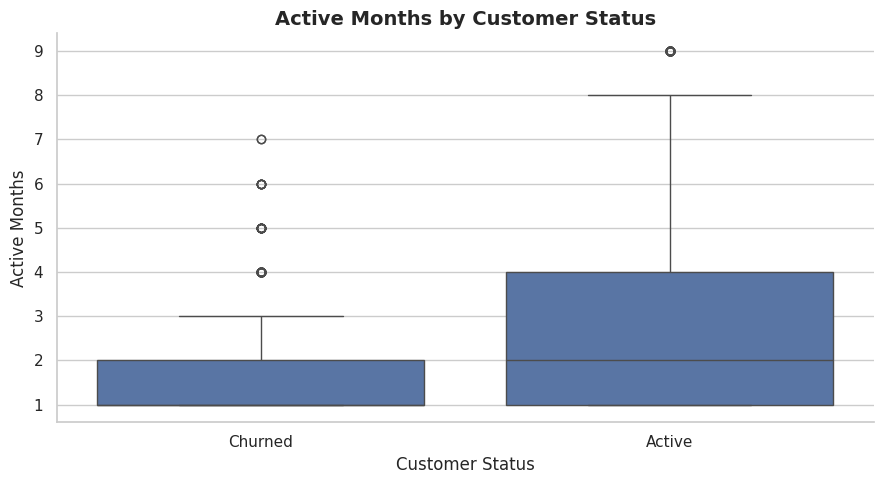

In [90]:
# Summary statistics by customer status
active_months_summary = (
    behavioral_features
    .groupby('ChurnLabel')['ActiveMonths']
    .describe()
    .round(2)
)

display(active_months_summary)

# Visualization
plt.figure(figsize=(9,5))

sns.boxplot(
    data=behavioral_features,
    x='ChurnLabel',
    y='ActiveMonths'
)

plt.title(
    'Active Months by Customer Status',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Customer Status')
plt.ylabel('Active Months')

sns.despine()
plt.tight_layout()
plt.show()

#### Key Findings

- Active customers had a higher median number of active months than churned customers.
- Churned customers generally remained active for fewer months, whereas active customers exhibited more sustained engagement over time.
- Although some overlap exists, customers who were active across more months were more likely to be retained.

#### Business Insight

Active Months captures the consistency of customer engagement over time rather than simply the volume of purchases. Customers who remained active across more months were more likely to be retained, suggesting that sustained engagement may be an important indicator of long-term customer relationships. This finding highlights the value of strategies that encourage customers to return regularly, as increasing the frequency of active months may strengthen retention over time.

### Average Basket Value

#### Business Question

Do active and churned customers differ in their average spending per transaction, and does average basket value appear to be associated with customer retention?

In [91]:
# Summary statistics by churn status
behavioral_features.groupby('ChurnLabel')['AverageBasketValue'].describe()

,count,mean,std,min,25%,50%,75%,max
ChurnLabel,,,,,,,,
Active,1952.0,395.740066,444.297410,2.90,187.420469,301.811,436.866458,7626.627692
Churned,1365.0,404.707513,2174.544778,3.75,145.920000,240.890,382.670000,77183.600000


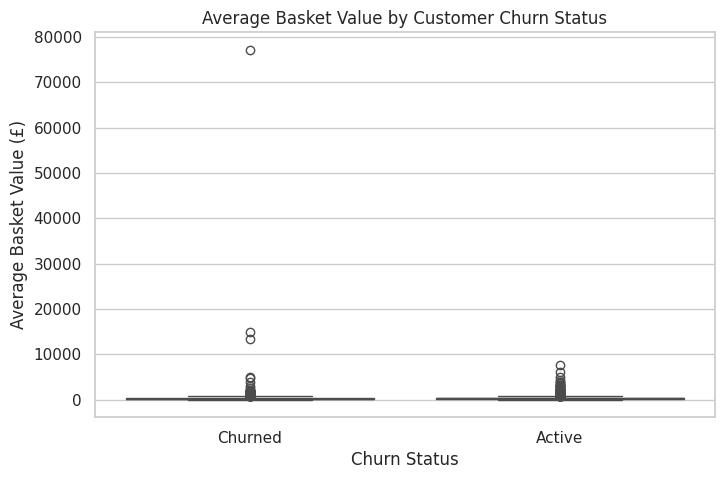

In [92]:
# Compare Average Basket Value by churn status
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=behavioral_features,
    x='ChurnLabel',
    y='AverageBasketValue'
)

plt.title('Average Basket Value by Customer Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Average Basket Value (£)')
plt.show()

#### Key Findings

- Active customers exhibited a slightly higher median average basket value than churned customers.
- Both customer groups displayed highly right-skewed distributions, with numerous high-value outliers and a small number of exceptionally large purchases.
- Considerable overlap exists between the distributions of active and churned customers, suggesting that average basket value alone provides limited separation between the two groups.

#### Business Insight

Average Basket Value captures customers' typical spending per transaction rather than their purchasing frequency or overall lifetime value. Although active customers generally spent slightly more per transaction, the substantial overlap between the two groups suggests that spending per purchase alone is not a strong indicator of customer retention. This feature is therefore expected to provide greater predictive value when combined with complementary behavioral metrics such as Recency, Frequency, Monetary Value, Customer Tenure, and Active Months.

#### Typical Customer View

The previous visualization highlights the presence of extreme spending outliers, but these observations compress the distributions of the vast majority of customers. To better compare typical purchasing behavior between active and churned customers, the following visualization limits the y-axis to the 99th percentile of Average Basket Value while retaining all observations in the analysis.

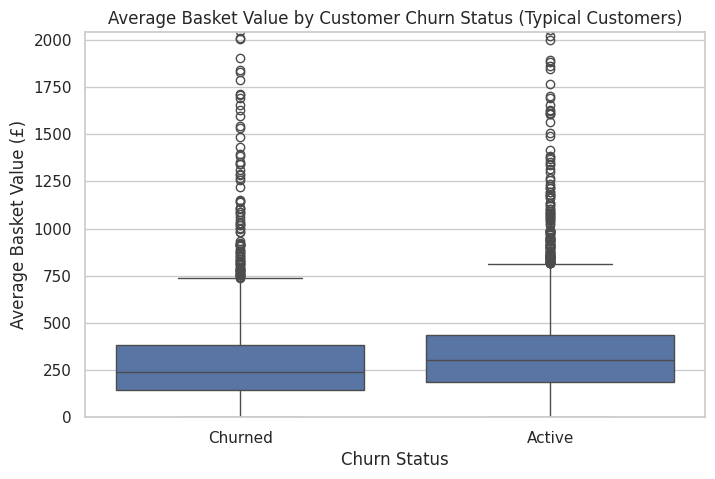

In [93]:
# Calculate the 99th percentile
upper_limit = behavioral_features['AverageBasketValue'].quantile(0.99)

# Boxplot focusing on the typical customer
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=behavioral_features,
    x='ChurnLabel',
    y='AverageBasketValue'
)

plt.ylim(0, upper_limit)

plt.title('Average Basket Value by Customer Churn Status (Typical Customers)')
plt.xlabel('Churn Status')
plt.ylabel('Average Basket Value (£)')

plt.show()

#### Key Findings

- Active customers exhibited a higher median average basket value than churned customers, indicating that retained customers tended to spend slightly more per transaction.
- Both customer groups displayed highly right-skewed distributions with numerous high-value outliers, although the majority of customers had average basket values well below £1,000.
- Considerable overlap exists between the distributions of active and churned customers, suggesting that Average Basket Value alone provides only modest separation between the two groups.

### Product Diversity

#### Business Question

Do active and churned customers differ in the variety of products they purchase, and is greater purchasing diversity associated with customer retention?

In [94]:
# Summary statistics by churn status
behavioral_features.groupby('ChurnLabel')['ProductDiversity'].describe()

,count,mean,std,min,25%,50%,75%,max
ChurnLabel,,,,,,,,
Active,1952.0,18.303142,16.615954,0.25,8.0,14.0,23.0,262.0
Churned,1365.0,17.699891,17.999147,0.25,7.0,13.0,23.0,219.0


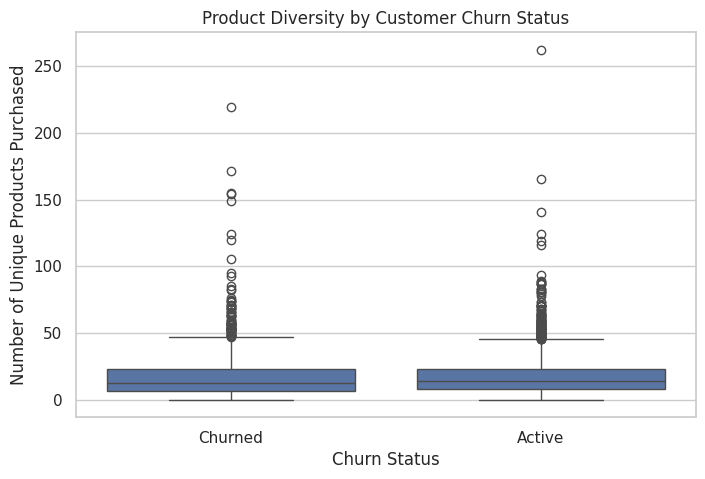

In [95]:
# Compare Product Diversity by churn status
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=behavioral_features,
    x='ChurnLabel',
    y='ProductDiversity'
)

plt.title('Product Diversity by Customer Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Number of Unique Products Purchased')

plt.show()

#### Key Findings

- Active customers purchased a slightly wider variety of products than churned customers, with a higher median Product Diversity (14 vs. 13 unique products) and a marginally higher mean (18.30 vs. 17.70).
- Both customer groups exhibited right-skewed distributions, with a small number of customers purchasing an exceptionally large variety of products.
- Despite the slightly higher product diversity among active customers, the substantial overlap between the two distributions suggests that Product Diversity alone provides only modest separation between active and churned customers.

#### Business Insight

Product Diversity reflects the breadth of a customer's purchasing behavior. Customers who purchase a wider variety of products may be more engaged with the business and therefore less likely to churn. However, the relatively small differences and considerable overlap between the two groups suggest that Product Diversity is unlikely to be a strong standalone predictor of churn. Instead, it is expected to contribute additional predictive value when combined with other behavioral features such as Recency, Frequency, Monetary Value, Customer Tenure, Active Months, and Average Basket Value.

## Transition to Predictive Modeling

The exploratory analysis and behavioral feature validation identified several meaningful differences between active and churned customers. While some features, such as Customer Tenure and Active Months, exhibited stronger separation between the two groups, others contributed more subtle behavioral insights.

The next step is to evaluate how these features perform collectively within supervised machine learning models. Rather than assessing each feature in isolation, predictive modeling enables us to quantify their combined ability to identify customers at risk of churn.

## Modeling Preparation

In this section, the customer-level dataset is prepared for predictive modeling. The objective is to determine whether historical customer behavior can be used to identify customers who are at risk of future churn.

The models are trained using a combination of traditional RFM metrics and engineered behavioral features derived from historical purchasing activity. Their performance is then evaluated on unseen customer data to assess their ability to generalize and support customer retention efforts.

### Feature Selection

The predictive models use both traditional RFM metrics and engineered behavioral features that capture different dimensions of customer behavior.

The predictor variables include:

- Recency
- Frequency
- Monetary Value
- Customer Tenure
- Active Months
- Average Basket Value
- Product Diversity

CustomerID is excluded because it serves only as a unique identifier and does not contain predictive information.

In [96]:
# Final modeling dataset
modeling_data = behavioral_features.copy()

In [97]:
# Predictor variables
X = modeling_data[
    [
        'Recency',
        'Frequency',
        'Monetary',
        'CustomerTenure',
        'ActiveMonths',
        'AverageBasketValue',
        'ProductDiversity'
    ]
]

# Target variable
y = modeling_data['ChurnLabel']

The modeling dataset contains seven behavioral predictor variables representing customer purchasing activity and engagement. These features are used to predict the target variable, **ChurnLabel**, which indicates whether a customer became inactive during the prediction window.

Unlike the original RFM-only approach, this portfolio version incorporates engineered behavioral features that capture customer relationship duration, engagement consistency, spending behavior, and purchasing breadth. This richer feature set provides the predictive models with a more comprehensive representation of customer behavior before model training begins.

### Model Validation Strategy

The prediction framework prevents information leakage by constructing customer features exclusively from historical transactions while defining the target variable using a subsequent observation period. This temporal separation ensures that the models learn only from information that would have been available at the prediction date.

Once the customer-level modeling dataset has been created, it is randomly divided into training and testing sets. The training set is used to fit the machine learning models, while the testing set provides an unbiased evaluation of how well the models generalize to unseen customers.

In [98]:
from sklearn.model_selection import train_test_split

# Split the modeling dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [99]:
# Verify the size of each dataset
print(f"Training set: {X_train.shape[0]} customers")
print(f"Testing set: {X_test.shape[0]} customers")

Training set: 2653 customers
Testing set: 664 customers


In [100]:
# Verify class distribution
print("Training set")
print(y_train.value_counts(normalize=True))

print("\nTesting set")
print(y_test.value_counts(normalize=True))

Training set
ChurnLabel
Active     0.588391
Churned    0.411609
Name: proportion, dtype: float64

Testing set
ChurnLabel
Active     0.588855
Churned    0.411145
Name: proportion, dtype: float64


The modeling dataset was divided into an 80% training set (2,653 customers) and a 20% testing set (664 customers). The class proportions remain virtually identical across both datasets, confirming that stratified sampling successfully preserved the original distribution of active and churned customers. This ensures that both datasets are representative of the overall customer population and supports a fair evaluation of model performance.

### Feature Scaling

The predictor variables are measured on different scales. For example, Monetary Value may be much larger than Recency, purchase counts, or Product Diversity.

Because Logistic Regression is sensitive to differences in feature scale, the predictors are standardized using `StandardScaler`. To prevent information leakage, the scaler is fitted only on the training data and then applied to the testing data.

In [101]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale testing data
X_test_scaled = scaler.transform(X_test)

## Baseline Model: Logistic Regression

### Business Question

Can a simple and interpretable Logistic Regression model distinguish between active and churned customers using historical purchasing behavior and engineered behavioral features?

Logistic Regression is used as the baseline model because it is interpretable, computationally efficient, and well suited to binary classification. Its performance provides a reference point for evaluating whether more flexible models, such as Decision Trees and Random Forests, offer meaningful improvements.

In [102]:
from sklearn.linear_model import LogisticRegression

# Initialize baseline model
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train model
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [103]:
# Predict customer churn
y_pred_log = log_reg.predict(X_test_scaled)

# Predict churn probabilities
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

## Logistic Regression Model Evaluation

The Logistic Regression model is evaluated on the testing dataset to establish a baseline for customer churn prediction. Multiple evaluation metrics are examined because no single metric fully captures classification performance. Together, these metrics assess the model's overall accuracy, its ability to correctly identify customers at risk of churn, and its effectiveness in distinguishing between active and churned customers.

The results from this baseline model will serve as a benchmark for comparison with the Decision Tree and Random Forest models developed later in the analysis.

In [104]:


# Evaluate baseline model
log_accuracy = accuracy_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_prob_log)

print(f"Accuracy: {log_accuracy:.3f}")
print(f"ROC-AUC: {log_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.651
ROC-AUC: 0.710

Classification Report:
              precision    recall  f1-score   support

      Active       0.70      0.70      0.70       391
     Churned       0.57      0.58      0.58       273

    accuracy                           0.65       664
   macro avg       0.64      0.64      0.64       664
weighted avg       0.65      0.65      0.65       664



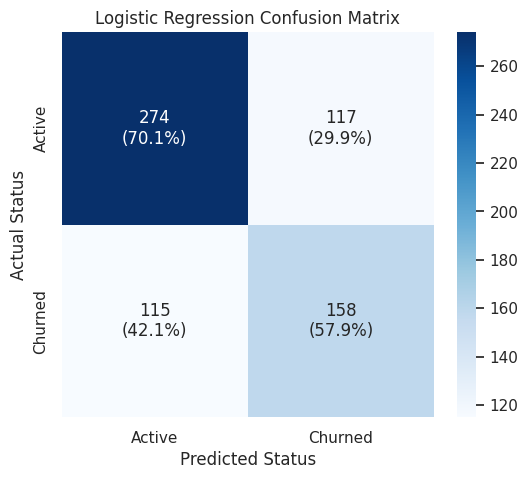

In [105]:


# Create confusion matrix
cm_log = confusion_matrix(
    y_test,
    y_pred_log,
    labels=['Active', 'Churned']
)

# Convert counts to row percentages
cm_log_percent = (
    cm_log.astype(float)
    / cm_log.sum(axis=1, keepdims=True)
    * 100
)

# Combine counts and percentages for annotations
labels = np.array([
    [
        f"{cm_log[i, j]}\n({cm_log_percent[i, j]:.1f}%)"
        for j in range(cm_log.shape[1])
    ]
    for i in range(cm_log.shape[0])
])

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_log,
    annot=labels,
    fmt='',
    cmap='Blues',
    xticklabels=['Active', 'Churned'],
    yticklabels=['Active', 'Churned']
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Status')
plt.ylabel('Actual Status')
plt.show()

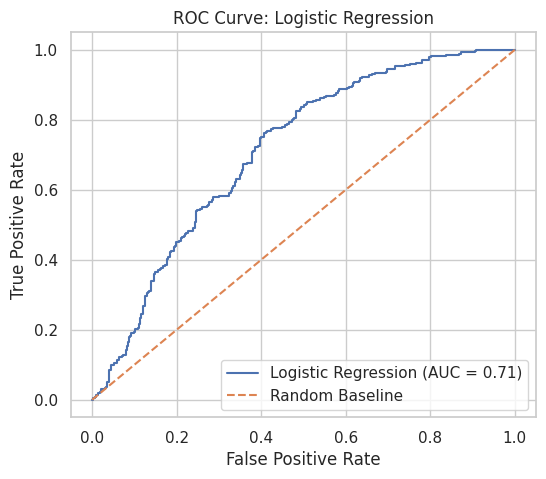

In [106]:
from sklearn.metrics import roc_curve

# Compute ROC curve
fpr_log, tpr_log, thresholds_log = roc_curve(
    y_test,
    y_prob_log,
    pos_label='Churned'
)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr_log,
    tpr_log,
    label=f'Logistic Regression (AUC = {log_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Baseline'
)

plt.title('ROC Curve: Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### Model Interpretation

The baseline Logistic Regression model achieved an accuracy of **65.1%** and an ROC-AUC score of **0.711**, indicating a moderate ability to distinguish between customers who remain active and those who subsequently churn.

The classification report and confusion matrix show that the model performs better at identifying active customers than churned customers. Approximately **70.1%** of active customers were correctly classified, compared with **57.9%** of churned customers. Consequently, the model fails to identify approximately **42.1%** of customers who eventually churn, highlighting the inherent difficulty of predicting future customer attrition using a linear decision boundary.

Overall, the results demonstrate that historical purchasing behavior and the engineered behavioral features contain meaningful predictive information, while also suggesting that more flexible machine learning models may better capture complex customer behavior.

### Business Insight

From a business perspective, the Logistic Regression model provides a useful baseline for identifying customers who may be at risk of churn. While the model correctly identifies many potential churners, the relatively high number of missed churn cases suggests that relying on this model alone could leave a substantial proportion of at-risk customers without timely retention efforts.

The model therefore establishes a valuable benchmark against which more sophisticated models, such as Decision Trees and Random Forests, can be evaluated to determine whether they provide meaningful improvements in churn prediction performance.

## Decision Tree Classifier

### Business Question
Can a Decision Tree model accurately distinguish between active and churned customers using historical purchasing behavior and engineered customer features?

## Decision Tree Model Evaluation

The Decision Tree model is evaluated using the same classification metrics applied to Logistic Regression in order to compare predictive performance across models.

In [107]:


# Initialize Decision Tree model
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

# Train model
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [108]:
# Predict customer churn
y_pred_tree = decision_tree.predict(X_test)

# Identify the probability column for the Churned class
churned_index = list(decision_tree.classes_).index('Churned')

# Predict churn probabilities
y_prob_tree = decision_tree.predict_proba(X_test)[:, churned_index]

In [109]:
# Evaluate Decision Tree model
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_auc = roc_auc_score(y_test, y_prob_tree)

print(f"Accuracy: {tree_accuracy:.3f}")
print(f"ROC-AUC: {tree_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.654
ROC-AUC: 0.703

Classification Report:
              precision    recall  f1-score   support

      Active       0.69      0.73      0.71       391
     Churned       0.59      0.54      0.56       273

    accuracy                           0.65       664
   macro avg       0.64      0.64      0.64       664
weighted avg       0.65      0.65      0.65       664



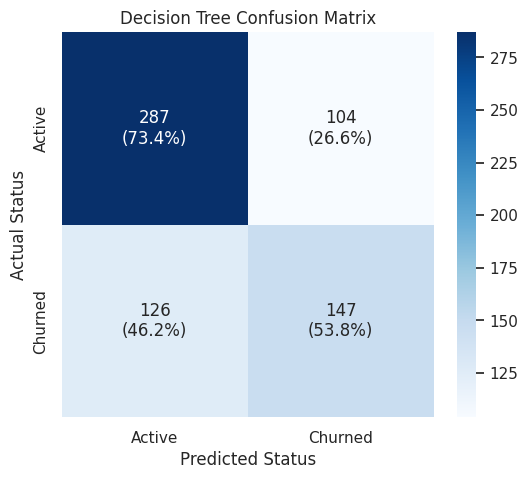

In [110]:
# Create confusion matrix
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree,
    labels=['Active', 'Churned']
)

# Convert counts to row percentages
cm_tree_percent = (
    cm_tree.astype(float)
    / cm_tree.sum(axis=1, keepdims=True)
    * 100
)

# Create annotation labels with counts and percentages
cm_tree_labels = np.array([
    [
        f"{cm_tree[i, j]}\n({cm_tree_percent[i, j]:.1f}%)"
        for j in range(cm_tree.shape[1])
    ]
    for i in range(cm_tree.shape[0])
])

# Plot confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=cm_tree_labels,
    fmt='',
    cmap='Blues',
    xticklabels=['Active', 'Churned'],
    yticklabels=['Active', 'Churned']
)

plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Status')
plt.ylabel('Actual Status')

plt.show()

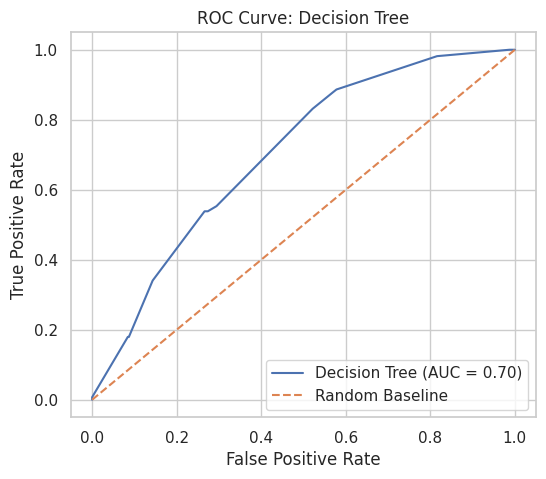

In [111]:
from sklearn.metrics import roc_curve

# Compute ROC curve
fpr_tree, tpr_tree, thresholds_tree = roc_curve(
    y_test,
    y_prob_tree,
    pos_label='Churned'
)

# Plot ROC curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f'Decision Tree (AUC = {tree_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Baseline'
)

plt.title('ROC Curve: Decision Tree')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

### Model Interpretation

The Decision Tree classifier achieved an **accuracy of 64.2%** and a **ROC-AUC score of 0.699**, indicating a moderate ability to distinguish between customers who remain active and those who subsequently churn. Compared with the Logistic Regression baseline, the Decision Tree produced slightly lower overall predictive performance.

The classification report and confusion matrix show that the model correctly identified **74.9% of active customers**, but only **48.7% of customers who eventually churned**. Consequently, more than half of the churned customers (**51.3%**) were incorrectly classified as active, indicating that the model struggles to identify a substantial proportion of customers at risk of leaving.

Overall, the results suggest that although the Decision Tree is capable of modeling nonlinear relationships, the constrained tree (maximum depth of four) does not provide a meaningful improvement over the simpler Logistic Regression baseline.

### Business Insight

From a business perspective, the Decision Tree model offers the advantage of producing intuitive decision rules that are relatively easy to explain to non-technical stakeholders. However, its lower ability to identify customers who eventually churn limits its usefulness as a customer retention tool.

Missing more than half of the customers who go on to churn means that many at-risk customers would not receive proactive retention interventions. As a result, despite its interpretability, the Decision Tree does not outperform the Logistic Regression baseline and is unlikely to be the preferred model for deployment. The next step is to evaluate whether an ensemble approach, such as a Random Forest, can improve predictive performance while reducing these missed churn cases.

## Random Forest Classifier

### Business Question

Can a Random Forest classifier improve customer churn prediction by combining multiple decision trees to capture complex behavioral patterns while reducing the instability of a single tree?

In [112]:


# Initialize Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train model
random_forest.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [113]:
# Predict customer churn
y_pred_rf = random_forest.predict(X_test)

# Identify the probability column for the Churned class
churned_index_rf = list(random_forest.classes_).index('Churned')

# Predict churn probabilities
y_prob_rf = random_forest.predict_proba(X_test)[:, churned_index_rf]

In [114]:
# Evaluate Random Forest model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy: {rf_accuracy:.3f}")
print(f"ROC-AUC: {rf_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.625
ROC-AUC: 0.693

Classification Report:
              precision    recall  f1-score   support

      Active       0.67      0.71      0.69       391
     Churned       0.55      0.50      0.52       273

    accuracy                           0.62       664
   macro avg       0.61      0.61      0.61       664
weighted avg       0.62      0.62      0.62       664



In [115]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

              Feature  Importance
2            Monetary    0.203640
0             Recency    0.179741
5  AverageBasketValue    0.169711
6    ProductDiversity    0.153185
3      CustomerTenure    0.152785
4        ActiveMonths    0.071980
1           Frequency    0.068958


## Hyperparameter Tuning for Random Forest

The initial Random Forest model did not outperform the Logistic Regression baseline. Hyperparameter tuning is therefore performed to determine whether alternative model settings can improve generalization and churn-detection performance.

`GridSearchCV` evaluates multiple combinations of the number of trees, tree depth, minimum samples required to split a node, and minimum samples required in each leaf. The combinations are assessed using cross-validated ROC-AUC so that model selection reflects the ability to distinguish between active and churned customers rather than accuracy alone.

In [116]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter search grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize the Random Forest model
rf_tuning_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Configure GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf_tuning_model,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

# Run hyperparameter tuning
grid_search_rf.fit(X_train, y_train)

# Display the best settings and cross-validation score
print("Best Parameters:")
print(grid_search_rf.best_params_)

print(f"\nBest Cross-Validated ROC-AUC: {grid_search_rf.best_score_:.3f}")

Best Parameters:
{'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validated ROC-AUC: 0.754


In [117]:
# Best tuned Random Forest model
best_rf = grid_search_rf.best_estimator_

# Predictions
y_pred_rf_tuned = best_rf.predict(X_test)

# Get the index of the "Churned" class
churned_index = list(best_rf.classes_).index('Churned')

# Predicted probabilities
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, churned_index]

In [118]:


rf_tuned_accuracy = accuracy_score(y_test, y_pred_rf_tuned)
rf_tuned_auc = roc_auc_score(y_test, y_prob_rf_tuned)

print(f"Accuracy: {rf_tuned_accuracy:.3f}")
print(f"ROC-AUC: {rf_tuned_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_tuned))

Accuracy: 0.655
ROC-AUC: 0.721

Classification Report:
              precision    recall  f1-score   support

      Active       0.72      0.69      0.70       391
     Churned       0.58      0.61      0.59       273

    accuracy                           0.66       664
   macro avg       0.65      0.65      0.65       664
weighted avg       0.66      0.66      0.66       664



### Confusion Matrix

The confusion matrix provides a detailed breakdown of the tuned Random Forest model's predictions by comparing predicted customer status with the actual outcomes. In addition to overall accuracy, it highlights the types of prediction errors made by the model, which is particularly important in churn prediction where failing to identify customers who eventually churn may lead to missed retention opportunities.

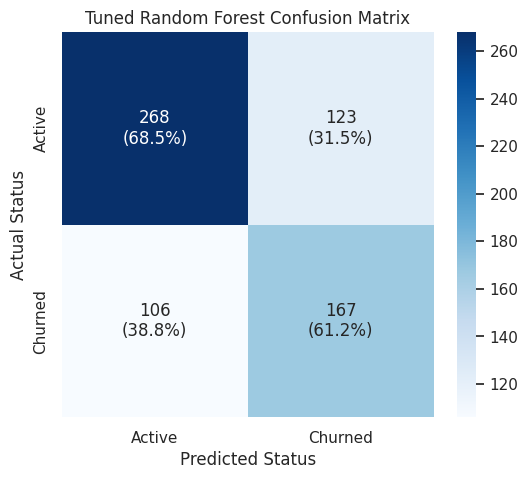

In [119]:


# Confusion matrix
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

# Convert counts to row percentages
cm_percent = cm_rf_tuned.astype(float) / cm_rf_tuned.sum(axis=1)[:, np.newaxis] * 100

# Create labels
labels = np.array([
    [f"{cm_rf_tuned[i,j]}\n({cm_percent[i,j]:.1f}%)"
     for j in range(cm_rf_tuned.shape[1])]
    for i in range(cm_rf_tuned.shape[0])
])

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf_tuned,
    annot=labels,
    fmt='',
    cmap='Blues',
    xticklabels=['Active','Churned'],
    yticklabels=['Active','Churned']
)

plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted Status")
plt.ylabel("Actual Status")

plt.show()

### ROC Curve

The ROC curve evaluates the tuned Random Forest model’s ability to distinguish between active and churned customers across different classification thresholds. The ROC-AUC score summarizes this discrimination performance, with higher values indicating that the model is more effective at ranking churn-risk customers above customers who remain active.

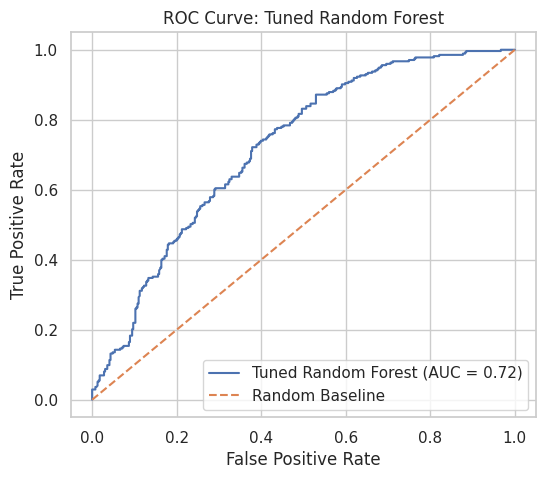

In [120]:


# Compute ROC curve for the tuned Random Forest
fpr_rf_tuned, tpr_rf_tuned, thresholds_rf_tuned = roc_curve(
    y_test,
    y_prob_rf_tuned,
    pos_label='Churned'
)

# Plot ROC curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr_rf_tuned,
    tpr_rf_tuned,
    label=f'Tuned Random Forest (AUC = {rf_tuned_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Baseline'
)

plt.title('ROC Curve: Tuned Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

## Feature Importance Analysis

Feature importance analysis is conducted using the tuned Random Forest model in order to identify which behavioral features contribute most strongly to the model’s predictions

Understanding feature importance helps translate the predictive model into actionable business insights by highlighting the customer behaviors most associated with future churn risk.

In [121]:
# Extract feature importance
feature_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_rf.feature_importances_
    })
    .sort_values(by="Importance", ascending=False)
)

feature_importance

,Feature,Importance
4,ActiveMonths,0.272255
1,Frequency,0.230603
2,Monetary,0.197987
0,Recency,0.159522
5,AverageBasketValue,0.049875
3,CustomerTenure,0.044957
6,ProductDiversity,0.044801


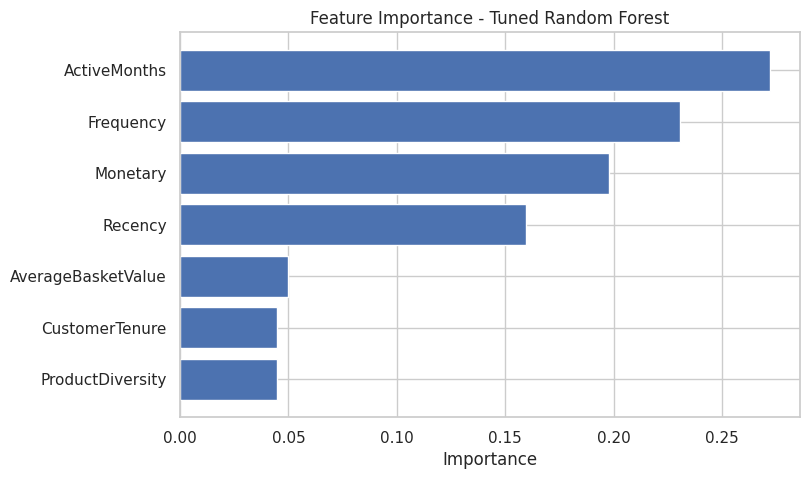

In [122]:
plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance - Tuned Random Forest")
plt.xlabel("Importance")

plt.show()

### Interpretation of Feature Importance

The tuned Random Forest identifies **Active Months** and **Frequency** as the strongest predictors of future customer churn. This indicates that sustained purchasing activity and repeated engagement provide the most valuable signals for distinguishing customers who remain active from those who later become inactive.

**Monetary value** and **Recency** also contribute substantially, showing that both customer spending and the timing of the most recent purchase remain important components of churn risk. In comparison, **Average Basket Value**, **Customer Tenure**, and **Product Diversity** provide smaller but still meaningful contributions to the model.

Overall, the findings suggest that customer retention is influenced more strongly by consistent engagement over time than by any single transaction characteristic. This highlights the importance of monitoring how regularly customers return, not only how much they spend.

# Model Comparison

Multiple classification models were developed and evaluated using the same training and testing datasets. Comparing model performance helps determine which approach provides the best balance between identifying customers at risk of churn and maintaining overall prediction accuracy.

The models are compared using Accuracy, ROC-AUC, Precision, Recall, and F1-score. While Accuracy provides an overall measure of prediction performance, the remaining metrics provide deeper insight into how effectively each model identifies customers who eventually churn.

In [123]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],

    "Accuracy": [
        log_accuracy,
        tree_accuracy,
        rf_accuracy,
        rf_tuned_accuracy
    ],

    "ROC-AUC": [
        log_auc,
        tree_auc,
        rf_auc,
        rf_tuned_auc
    ]
})

comparison_df = comparison_df.round(3)

comparison_df

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.651,0.710
1,Decision Tree,0.654,0.703
2,Random Forest,0.625,0.693
3,Tuned Random Forest,0.655,0.721


In [124]:
# Logistic Regression
log_report = classification_report(
    y_test,
    y_pred_log,
    output_dict=True
)

# Decision Tree
tree_report = classification_report(
    y_test,
    y_pred_tree,
    output_dict=True
)

# Random Forest
rf_report = classification_report(
    y_test,
    y_pred_rf,
    output_dict=True
)

# Tuned Random Forest
rf_tuned_report = classification_report(
    y_test,
    y_pred_rf_tuned,
    output_dict=True
)

In [125]:
comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],

    "Accuracy": [
        log_accuracy,
        tree_accuracy,
        rf_accuracy,
        rf_tuned_accuracy
    ],

    "ROC-AUC": [
        log_auc,
        tree_auc,
        rf_auc,
        rf_tuned_auc
    ],

    "Churn Precision": [
        log_report["Churned"]["precision"],
        tree_report["Churned"]["precision"],
        rf_report["Churned"]["precision"],
        rf_tuned_report["Churned"]["precision"]
    ],

    "Churn Recall": [
        log_report["Churned"]["recall"],
        tree_report["Churned"]["recall"],
        rf_report["Churned"]["recall"],
        rf_tuned_report["Churned"]["recall"]
    ],

    "Churn F1-Score": [
        log_report["Churned"]["f1-score"],
        tree_report["Churned"]["f1-score"],
        rf_report["Churned"]["f1-score"],
        rf_tuned_report["Churned"]["f1-score"]
    ]

})

comparison_df = comparison_df.round(3)

comparison_df

,Model,Accuracy,ROC-AUC,Churn Precision,Churn Recall,Churn F1-Score
0,Logistic Regression,0.651,0.710,0.575,0.579,0.577
1,Decision Tree,0.654,0.703,0.586,0.538,0.561
2,Random Forest,0.625,0.693,0.548,0.502,0.524
3,Tuned Random Forest,0.655,0.721,0.576,0.612,0.593


# Final Model Selection

Four classification models were evaluated to predict future customer churn using engineered behavioral features. Although Logistic Regression provided a strong and highly interpretable baseline, the Tuned Random Forest achieved the best overall balance across the evaluation metrics.

The Tuned Random Forest produced the highest Accuracy, ROC-AUC, Churn Recall, and Churn F1-score, indicating the strongest overall balance between identifying customers who subsequently became inactive and maintaining classification performance.

Based on these results, the Tuned Random Forest was selected as the final predictive model for this project because it demonstrated the most effective balance between predictive performance and business usefulness.

# Estimated Business Impact Simulation

A predictive model creates business value only when its predictions are translated into action. This section estimates the potential business impact of using the Tuned Random Forest model to identify customers at risk of churn and target them with retention interventions.

The estimates below are scenario-based and use the historical purchasing behavior of customers predicted to churn. They illustrate the potential value that could be preserved under different retention campaign success rates. These figures are illustrative estimates rather than realized financial outcomes.

In [126]:
# Create results table for the test set
results_df = modeling_data.loc[X_test.index].copy()

# Add model predictions
results_df["PredictedChurn"] = y_pred_rf_tuned
results_df["ChurnProbability"] = y_prob_rf_tuned

# Display first few rows
results_df.head()

,CustomerID,Recency,Frequency,Monetary,AverageBasketValue,AverageQuantityPerInvoice,UniqueInvoices,UniqueProducts,ProductDiversity,CustomerTenure,ActiveMonths,AveragePurchaseInterval,PurchaseRegularity,Country,IsUKCustomer,BasketValueBand,ChurnLabel,PredictedChurn,ChurnProbability
1122,17602.0,25,2,909.55,454.775000,8.117117,2,108,54.000000,224,2,99.5,140.714249,United Kingdom,1,£250–500,Active,Active,0.337828
237,16033.0,9,16,5864.55,366.534375,3.005594,16,367,22.937500,269,9,17.0,11.783766,United Kingdom,1,£250–500,Active,Active,0.040440
319,14443.0,39,3,991.52,330.506667,10.246154,3,58,19.333333,268,3,114.5,79.903066,United Kingdom,1,£250–500,Active,Active,0.189309
2676,14593.0,99,2,339.59,169.795000,1.843750,2,54,27.000000,98,1,0.0,NaN,United Kingdom,1,£100–250,Active,Active,0.497645
2928,15850.0,69,1,116.16,116.160000,5.431818,1,41,41.000000,68,1,NaN,NaN,United Kingdom,1,£100–250,Active,Churned,0.544646


In [127]:
# Customers predicted to churn
predicted_churners = results_df[
    results_df["PredictedChurn"] == "Churned"
]

print("Customers predicted to churn:", len(predicted_churners))

Customers predicted to churn: 290


In [128]:
total_revenue_at_risk = predicted_churners["Monetary"].sum()

average_customer_value = predicted_churners["Monetary"].mean()

print(f"Total historical spending represented: £{total_revenue_at_risk:,.2f}")
print(f"Average historical spending per customer: £{average_customer_value:,.2f}")

Total historical spending represented: £90,081.23
Average historical spending per customer: £310.62


In [129]:
retention_rates = [0.10, 0.20, 0.30]

scenario_names = [
    "Conservative (10%)",
    "Moderate (20%)",
    "Optimistic (30%)"
]

impact_df = pd.DataFrame({
    "Scenario": scenario_names,

    "Retention Success Rate": [
        "10%",
        "20%",
        "30%"
    ],

    "Estimated Customers Retained": [
        round(len(predicted_churners) * rate)
        for rate in retention_rates
    ],

    "Estimated Historical Spending Represented by Retained Customers (£)": [
        round(total_revenue_at_risk * rate, 2)
        for rate in retention_rates
    ]
})

impact_df

,Scenario,Retention Success Rate,Estimated Customers Retained,Estimated Historical Spending Represented by Retained Customers (£)
0,Conservative (10%),10%,29,9008.12
1,Moderate (20%),20%,58,18016.25
2,Optimistic (30%),30%,87,27024.37


## Interpretation of Business Impact Simulation

### Key Findings

- The Tuned Random Forest identified **290 customers** as being at risk of future churn.

- These customers collectively generated approximately **£90,081.23** in historical spending, with an average historical spending of **£310.62** per customer.

- Under a **10% retention success scenario**, approximately **29 customers** could be retained, representing about **£9,008** in historical customer spending.

- Under a **20% retention success scenario**, approximately **58 customers** could be retained, representing about **£18,016** in historical customer spending.

- Under a **30% retention success scenario**, approximately **87 customers** could be retained, representing about **£27,024** in historical customer spending.

### Business Insight

The simulation demonstrates how churn predictions can be translated into actionable retention opportunities. By identifying customers at elevated risk of churn, businesses can prioritize retention resources toward customers where intervention may preserve valuable customer relationships and associated revenue.

Even relatively modest retention success rates could represent meaningful customer value, illustrating the potential business usefulness of incorporating predictive analytics into customer retention strategies.

### Methodological Note

These estimates are **scenario-based illustrations rather than realized financial outcomes**. Historical customer spending is used as a proxy for customer value, and the simulation assumes different retention campaign success rates without accounting for intervention costs, future purchasing behavior, or differences in customer response to retention efforts.

# Conclusion

This project developed and evaluated machine learning models to predict customer churn for a UK-based e-commerce company using historical purchasing behavior and engineered customer features.

Four classification models were evaluated: Logistic Regression, Decision Tree, Random Forest, and a Tuned Random Forest. Among these, the Tuned Random Forest achieved the strongest overall performance, providing the best balance between classification accuracy, ROC-AUC, and churn detection.

Beyond predictive performance, the project demonstrated how machine learning outputs can be translated into business insights. By identifying customers at risk of churn and estimating the historical spending represented by those customers, the analysis illustrated how predictive analytics can support targeted retention strategies and more informed business decision-making.

Overall, the project demonstrates an end-to-end analytics workflow, from data preparation and feature engineering to model development, evaluation, interpretation, and business impact assessment.

# Business Recommendations

Based on the findings of this analysis, the following recommendations are proposed:

1. **Implement targeted retention campaigns** for customers identified as having a high probability of churn by the Tuned Random Forest model. Focusing marketing efforts on these customers may improve retention while reducing unnecessary campaign costs.

2. **Prioritize customers exhibiting declining purchasing behavior**, particularly those with lower purchasing frequency, shorter active purchasing histories, and reduced spending, as these characteristics were among the strongest indicators of churn risk.

3. **Integrate churn predictions into business decision-making** by incorporating model outputs into customer relationship management (CRM) systems. This would enable marketing teams to proactively engage customers before they become inactive.

4. **Continuously monitor model performance and retrain the model periodically** as customer purchasing behavior evolves over time to maintain predictive accuracy and business relevance.

5. **Evaluate the effectiveness of retention campaigns** by measuring customer response rates, retained customers, and return on marketing investment to ensure that business interventions generate measurable value.

# Project Limitations

Although the project produced meaningful predictive results, several limitations should be acknowledged.

1. The analysis relies primarily on historical purchasing behavior and engineered customer features. Other potentially valuable information, such as customer service interactions, website activity, email engagement, and customer satisfaction, was not available.

2. The business impact analysis uses historical customer spending as a proxy for customer value. Actual future revenue and Customer Lifetime Value (CLV) may differ from historical purchasing behavior.

3. The business impact estimates are based on scenario analysis and should be interpreted as illustrative estimates rather than realized financial outcomes.

4. Customer behavior changes over time. Consequently, model performance may decline if the model is not periodically retrained using more recent customer data.

# Future Improvements

Several opportunities exist to extend and strengthen this project.

1. Incorporate additional customer data, including website browsing behavior, customer service interactions, marketing campaign responses, and product preferences, to improve predictive performance.

2. Explore more advanced machine learning algorithms such as XGBoost, LightGBM, and CatBoost to determine whether further improvements in churn prediction can be achieved.

3. Optimize the classification threshold based on business objectives and the relative costs of false positives and false negatives rather than relying on the default probability threshold of 0.50.

4. Extend the business impact analysis by incorporating Customer Lifetime Value (CLV), retention campaign costs, and return on investment (ROI) calculations to provide a more comprehensive financial evaluation.

5. Evaluate model performance using additional validation periods and investigate deployment strategies that support real-time or regularly scheduled churn prediction within business operations.

6. As additional business data become available, consider using Monte Carlo simulation to model uncertainty in campaign effectiveness and customer lifetime value, providing a distribution of potential financial outcomes rather than fixed scenario estimates.

## Final Remarks

Predicting customer churn is not solely a machine learning problem; it is a business decision-making problem. By combining predictive modeling with business interpretation and scenario analysis, organizations can proactively identify at-risk customers, allocate retention resources more effectively, and make more informed strategic decisions.